**UNIVERSIDADE DE SÃO PAULO**<br>
**MBA DATA SCIENCE & ANALYTICS USP/ESALQ**<br>
**Encontro para resolução de exercícios adicionais: Árvores e Ensemble Models**<br>
**Prof. Dr. Wilson Tarantin Junior**<br>
Aluna: Luiza Batista Laquini<br>
Turma: DSA 241<br>

*coding: utf-8*

In [10]:
#%% Importar os pacotes

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

In [11]:
#%% Importar o banco de dados

dados = pd.read_csv("data/dados_carros.csv")
# Fonte: https://www.kaggle.com/datasets/gabrielsantello/cars-purchase-decision-dataset?select=car_data.csv

In [12]:
dados.head()

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0


In [13]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


In [14]:
#%% Limpeza dos dados

# Remover colunas que não serão utilizadas
dados.drop(columns=['User ID'], inplace=True)

In [15]:
#%% Estatísticas descritivas das variáveis

# Variáveis métricas
print(dados[['Age','AnnualSalary']].describe(),'\n')

# Variáveis categóricas
print(dados['Gender'].value_counts(),'\n')
print(dados['Purchased'].value_counts(),'\n')

               Age   AnnualSalary
count  1000.000000    1000.000000
mean     40.106000   72689.000000
std      10.707073   34488.341867
min      18.000000   15000.000000
25%      32.000000   46375.000000
50%      40.000000   72000.000000
75%      48.000000   90000.000000
max      63.000000  152500.000000 

Gender
Female    516
Male      484
Name: count, dtype: int64 

Purchased
0    598
1    402
Name: count, dtype: int64 



In [16]:
#%% Transformando variáveis explicativas categóricas em dummies

dados = pd.get_dummies(dados, 
                       columns=['Gender'], 
                       drop_first=True,
                       dtype='int')

In [17]:
#%% Separando as variáveis Y e X

X = dados.drop(columns=['Purchased'])
y = dados['Purchased']

#%% Separando as amostras de treino e teste

# Vamos escolher 70% das observações para treino e 30% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=100)

In [18]:
#%%######################### Árvore de Decisão ################################
###############################################################################
#%% Gerando a árvore de decisão

# Vamos iniciar com uma árvore pequena: profundidade máxima 2 (max_depth)
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=100)
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=100)

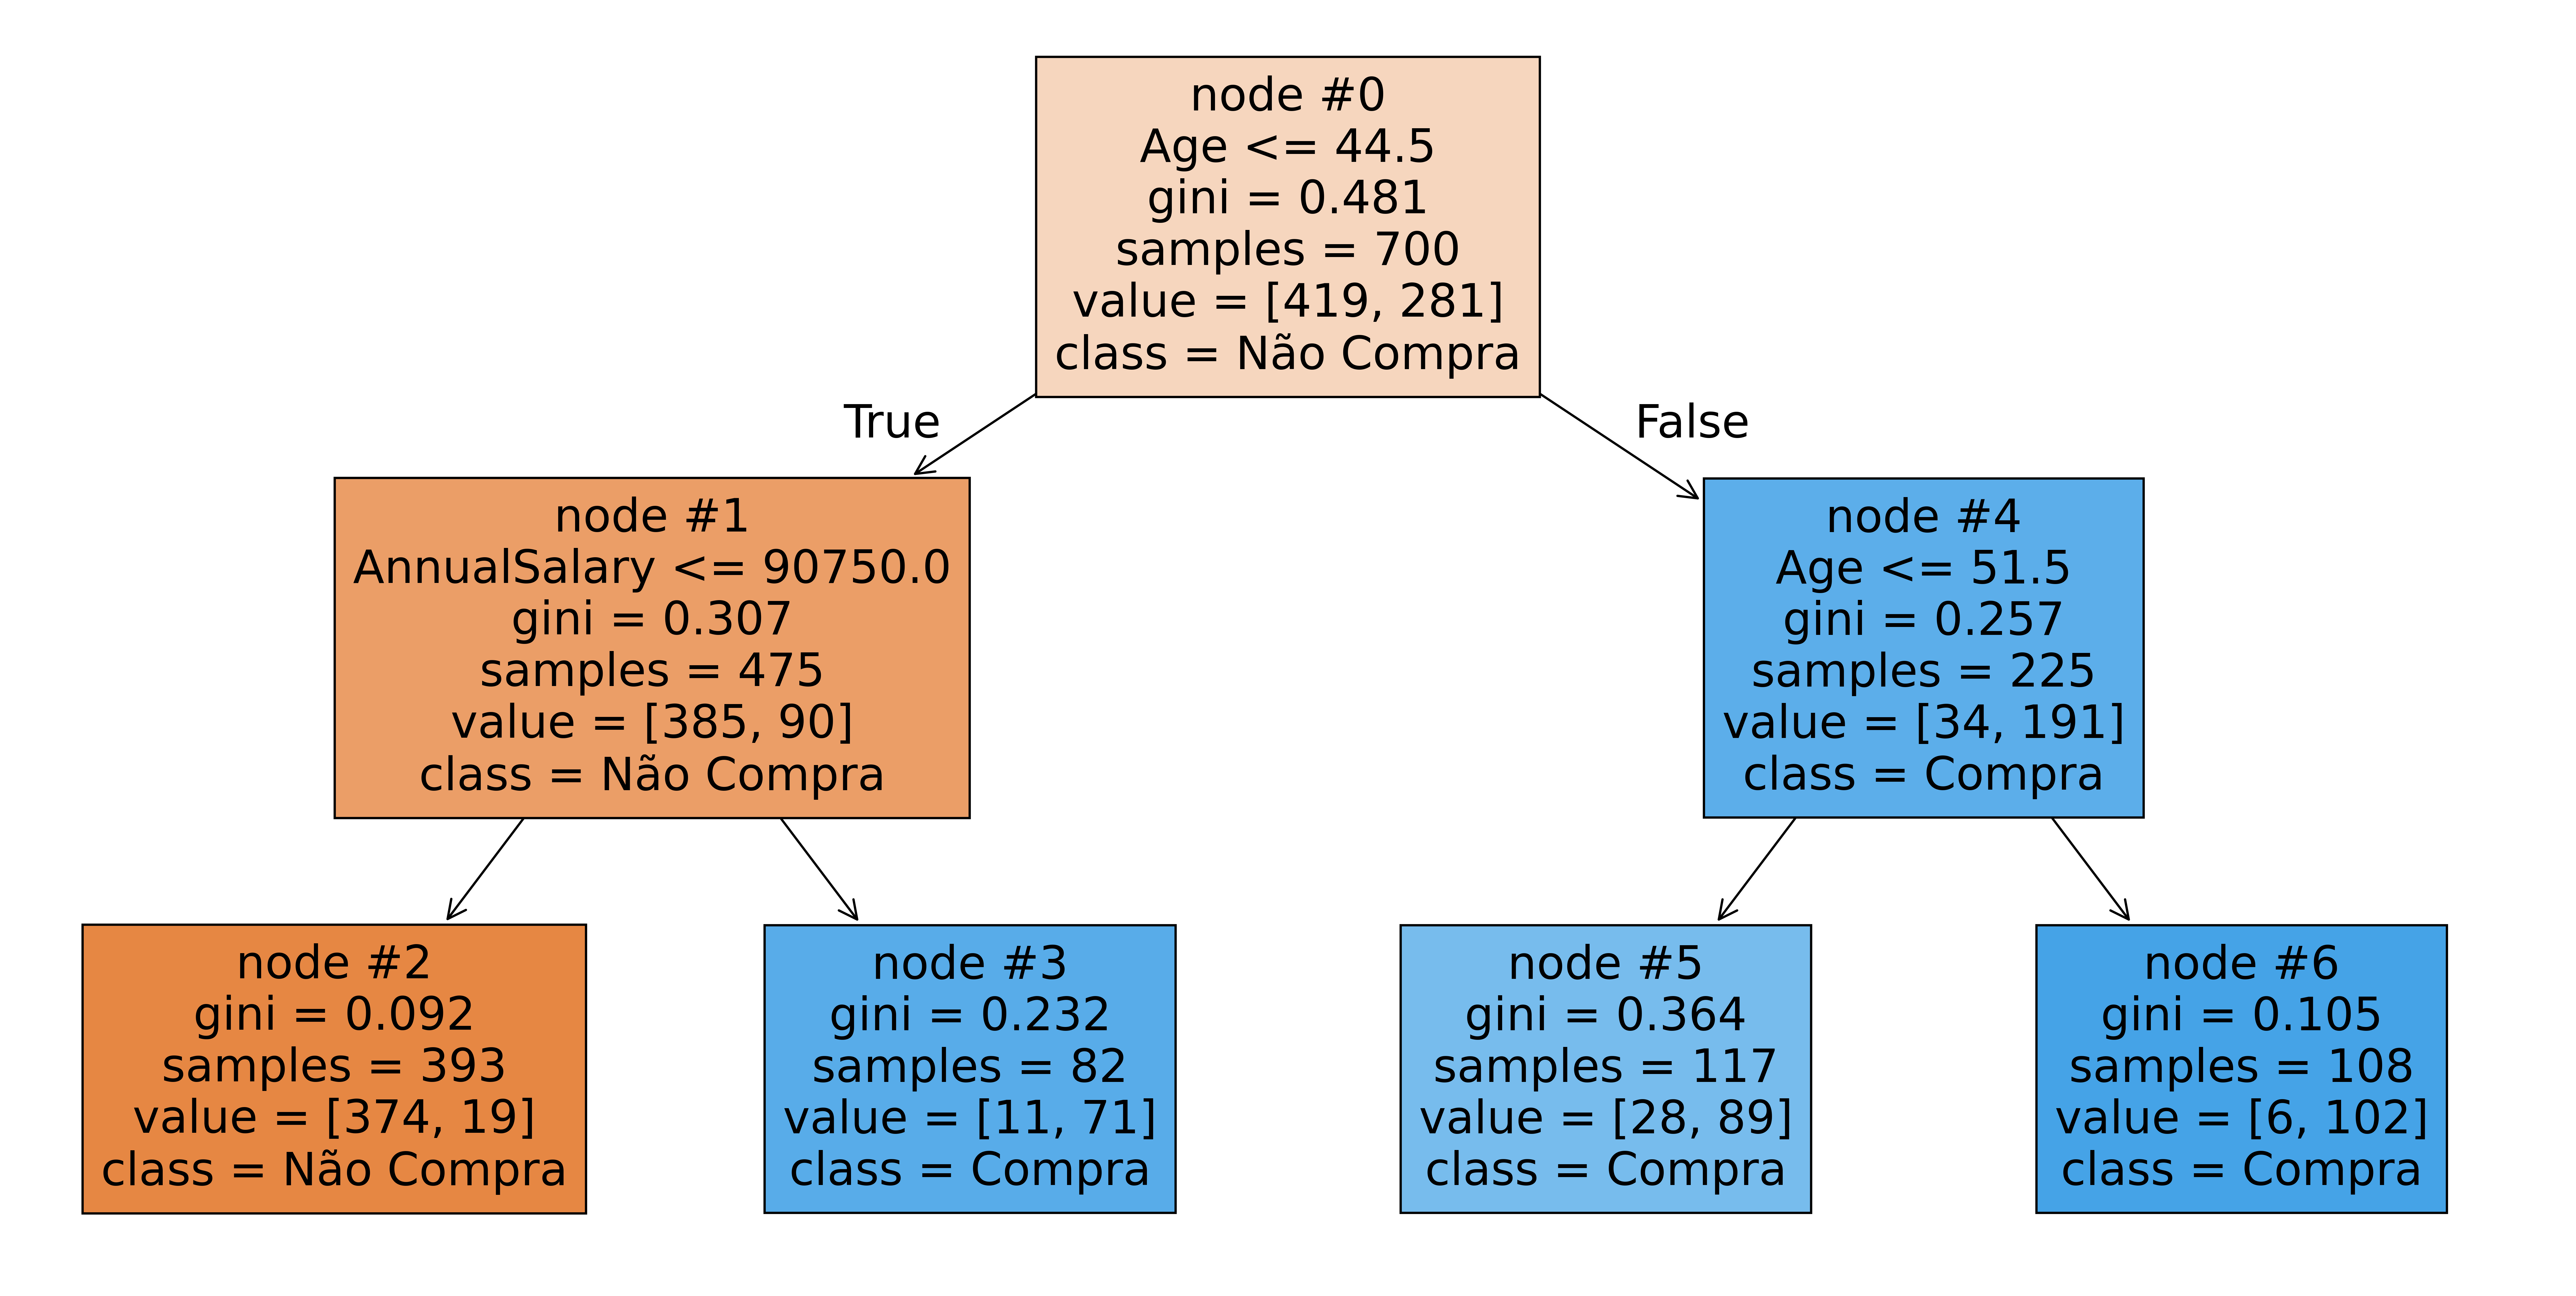

In [19]:
#%% Plotando a árvore

plt.figure(figsize=(20,10), dpi=600)
plot_tree(tree_clf,
          feature_names=X.columns.tolist(),
          class_names=['Não Compra','Compra'],
          proportion=False,
          filled=True,
          node_ids=True)
plt.show()

In [20]:
#%% Analisando os resultados dos splits

tree_split = pd.DataFrame(tree_clf.cost_complexity_pruning_path(X_train, y_train))
tree_split.sort_index(ascending=False, inplace=True)

print(tree_split)

   ccp_alphas  impurities
3    0.189683    0.480567
2    0.129547    0.290885
1    0.005418    0.161337
0    0.000000    0.155919


In [21]:
#%% Importância das variáveis preditoras

tree_features = pd.DataFrame({'features':X.columns.tolist(),
                              'importance':tree_clf.feature_importances_})

print(tree_features)

       features  importance
0           Age    0.600961
1  AnnualSalary    0.399039
2   Gender_Male    0.000000


In [22]:
#%% Obtendo os valores preditos pela árvore

# Predict na base de treinamento
tree_pred_train_class = tree_clf.predict(X_train)
tree_pred_train_prob = tree_clf.predict_proba(X_train)

# Predict na base de testes
tree_pred_test_class = tree_clf.predict(X_test)
tree_pred_test_prob = tree_clf.predict_proba(X_test)

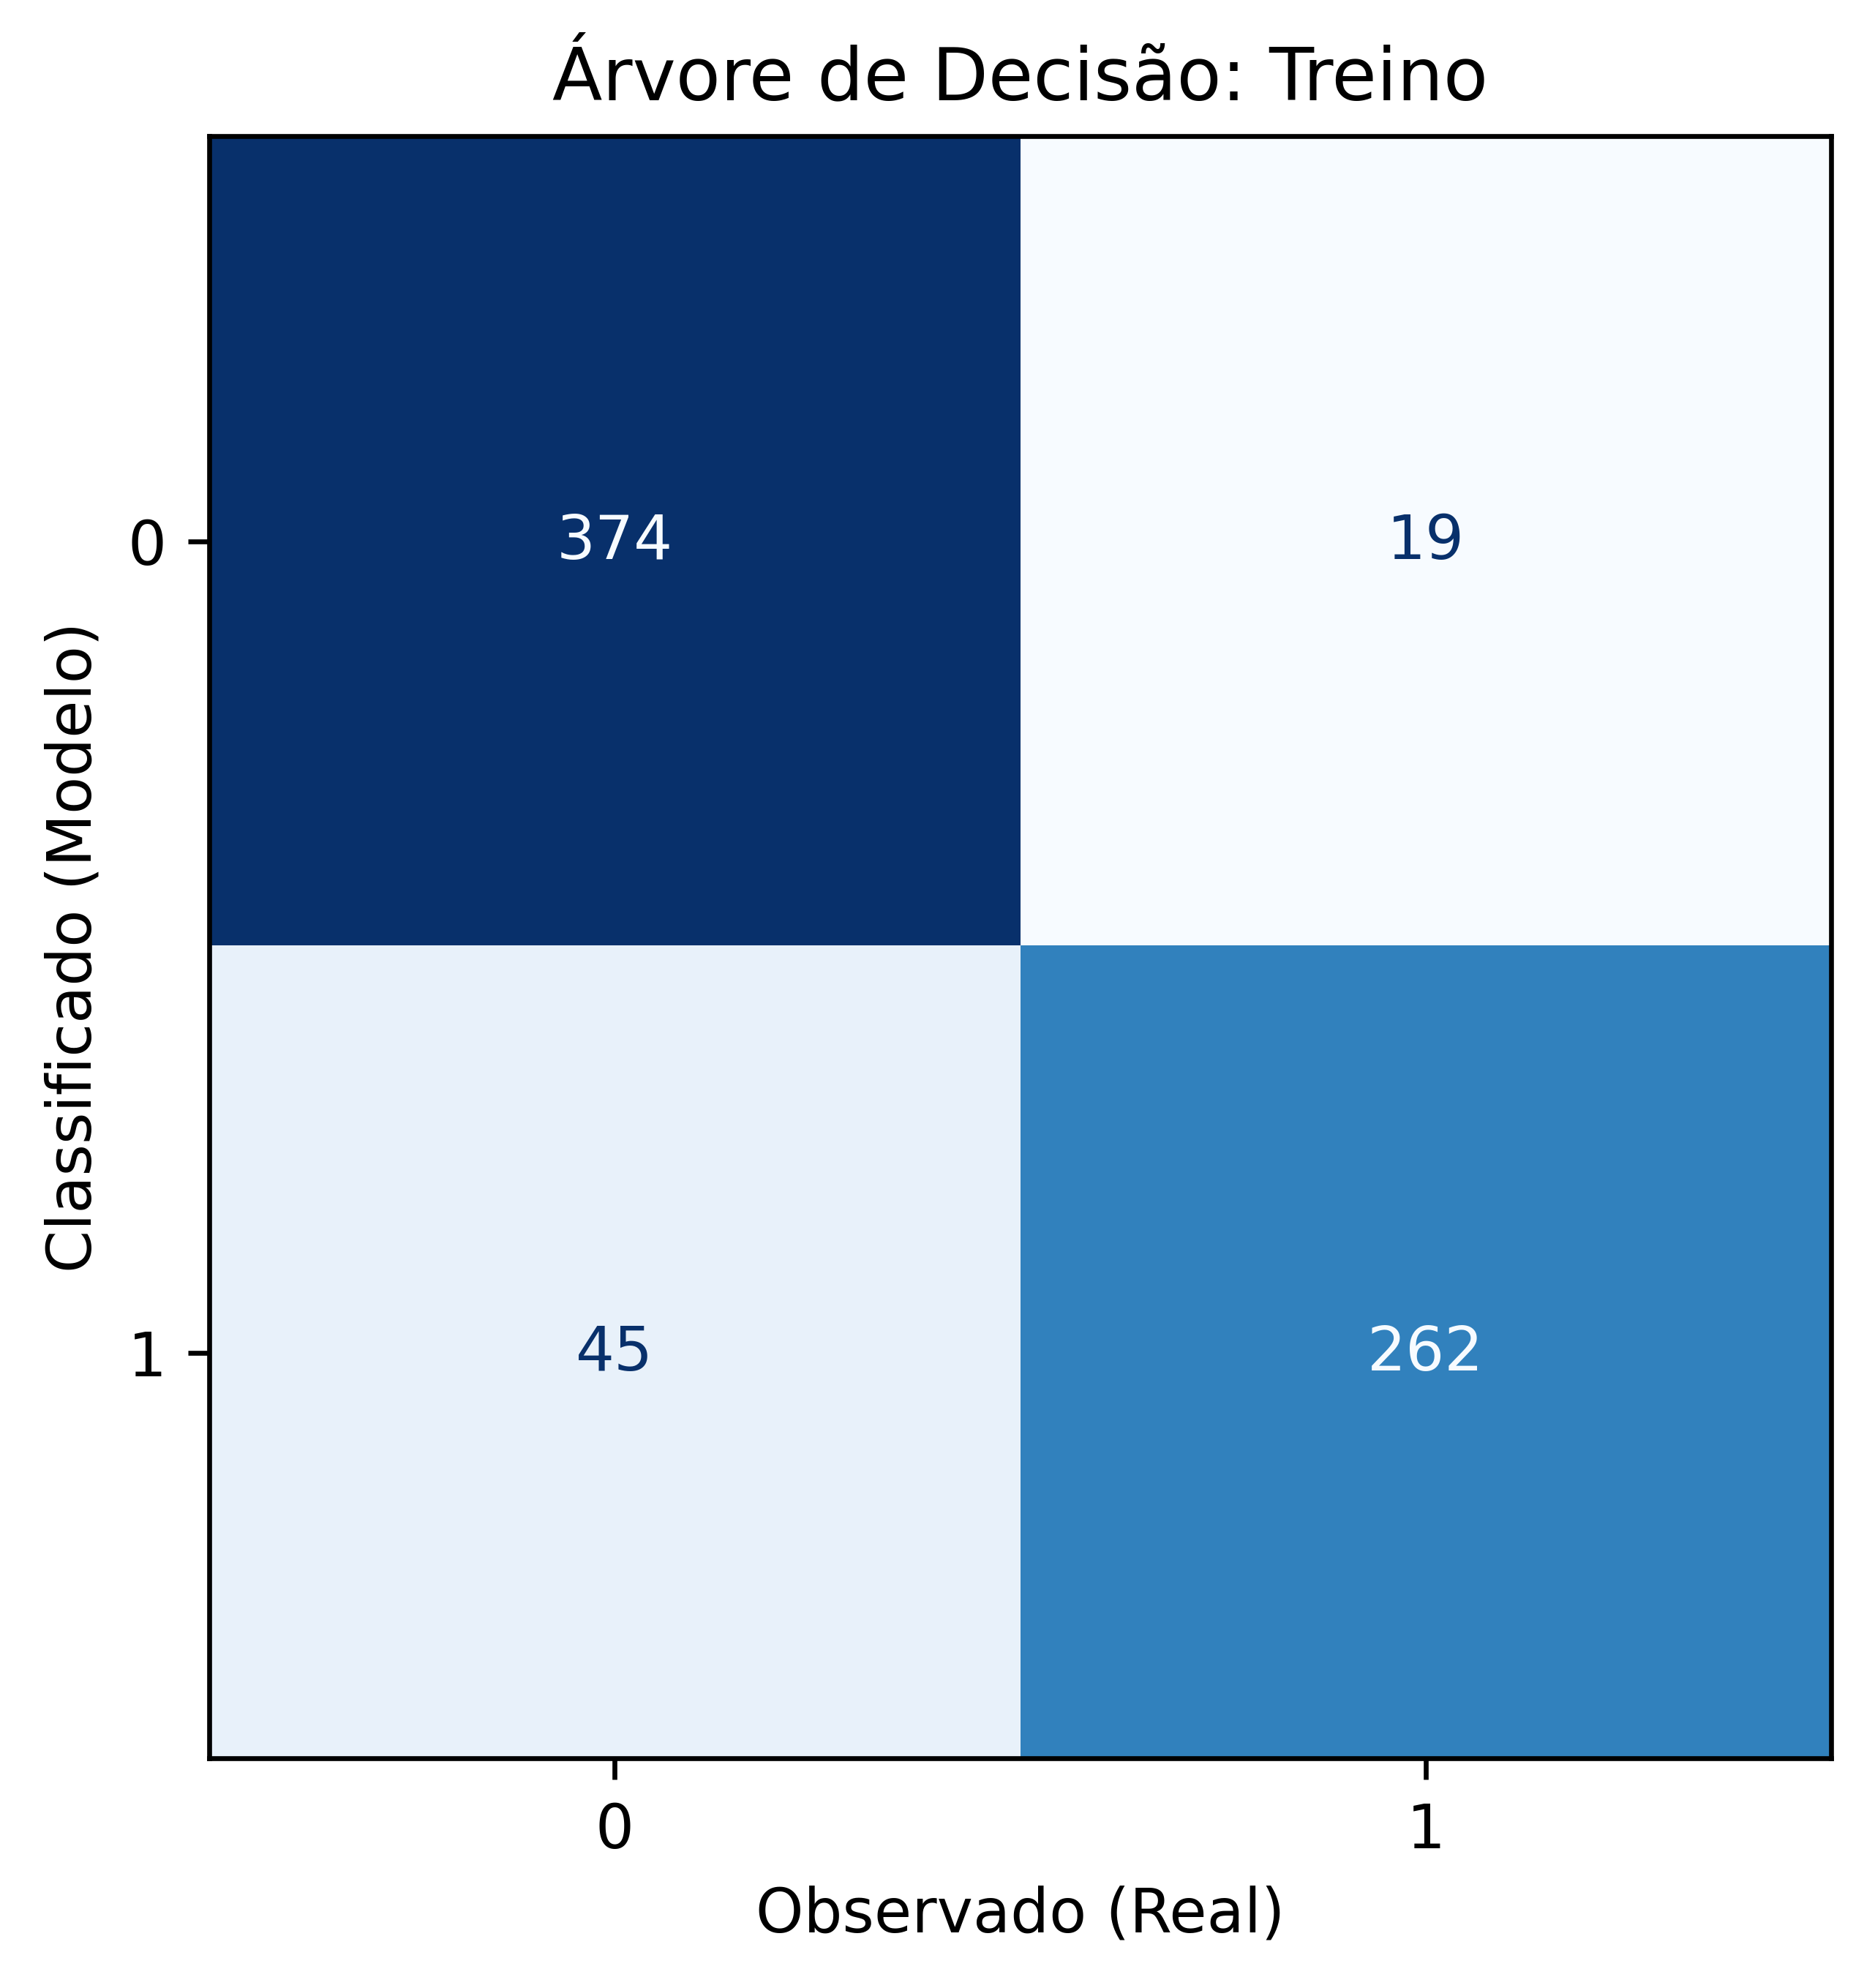

Avaliação da Árvore (Base de Treino)
Acurácia: 90.9%
Sensibilidade: 93.2%
Especificidade: 89.3%
Precision: 85.3%


In [23]:
#%% Matriz de confusão (base de treino)

tree_cm_train = confusion_matrix(tree_pred_train_class, y_train)
cm_train_disp_tree = ConfusionMatrixDisplay(tree_cm_train)

plt.rcParams['figure.dpi'] = 600
cm_train_disp_tree.plot(colorbar=False, cmap='Blues')
plt.title('Árvore de Decisão: Treino')
plt.xlabel('Observado (Real)')
plt.ylabel('Classificado (Modelo)')
plt.show()

acc_tree_train = accuracy_score(y_train, tree_pred_train_class)
sens_tree_train = recall_score(y_train, tree_pred_train_class, pos_label=1)
espec_tree_train = recall_score(y_train, tree_pred_train_class, pos_label=0)
prec_tree_train = precision_score(y_train, tree_pred_train_class)

print("Avaliação da Árvore (Base de Treino)")
print(f"Acurácia: {acc_tree_train:.1%}")
print(f"Sensibilidade: {sens_tree_train:.1%}")
print(f"Especificidade: {espec_tree_train:.1%}")
print(f"Precision: {prec_tree_train:.1%}")

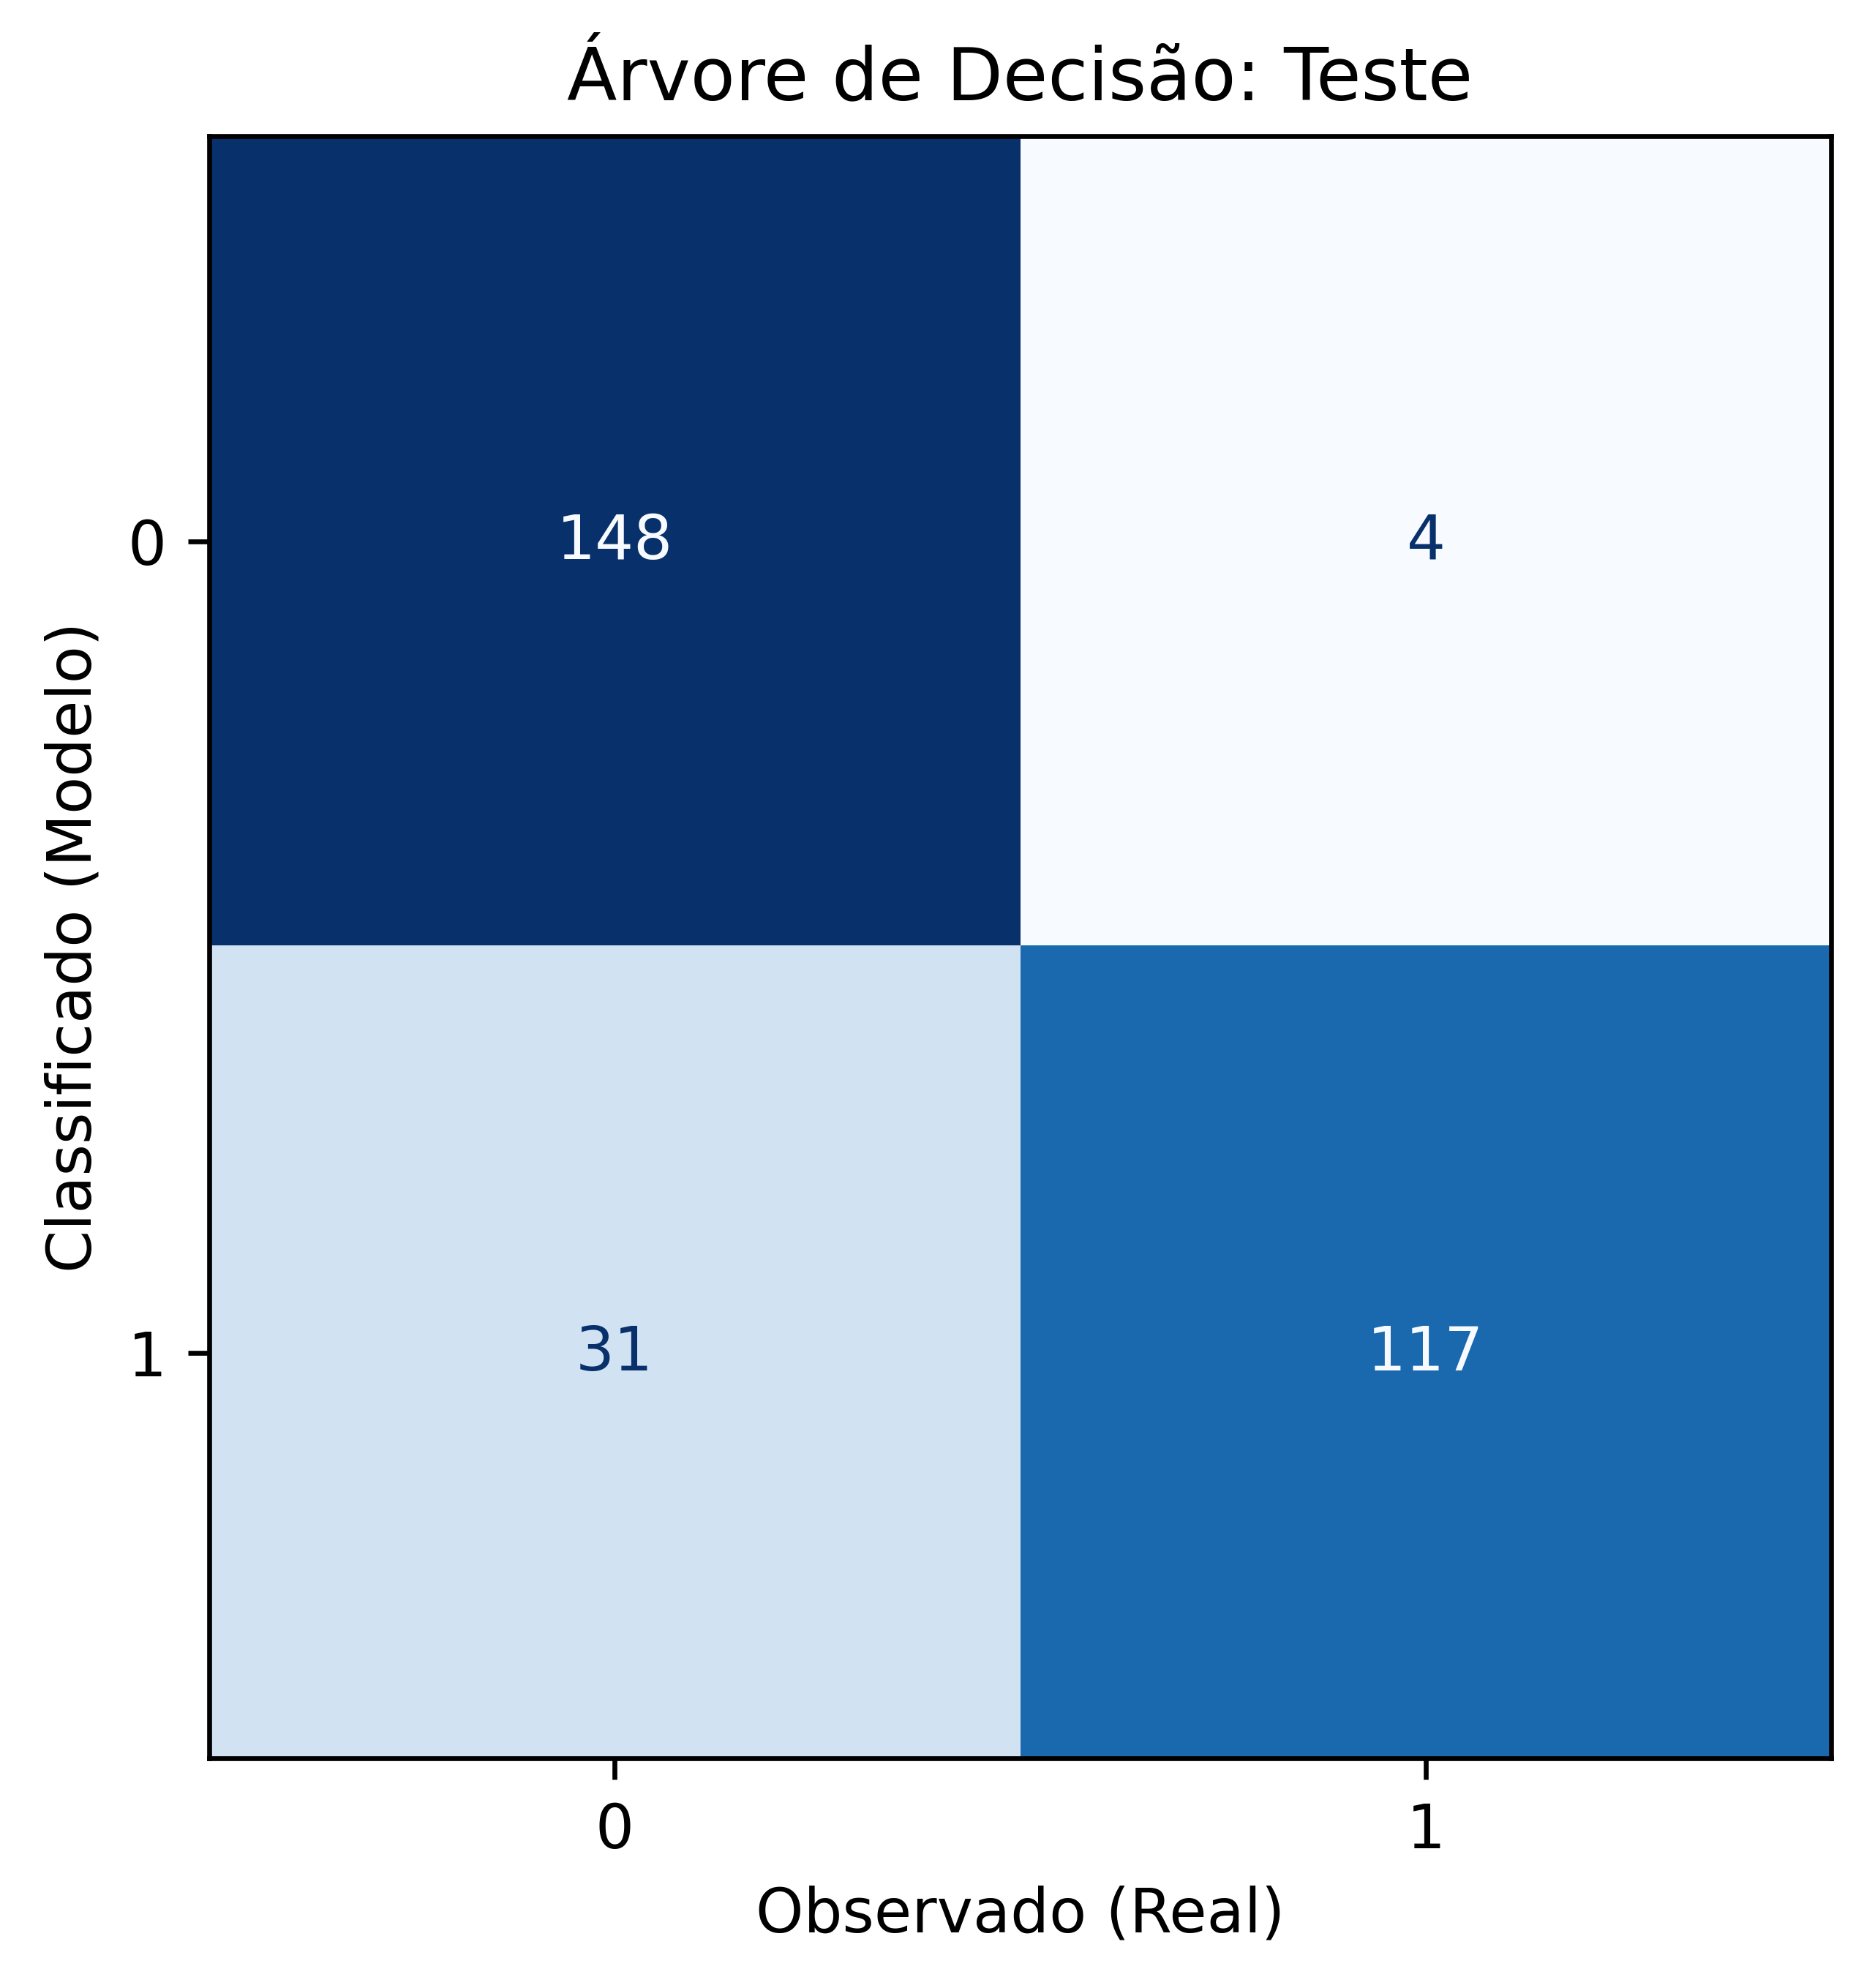

Avaliação da Árvore (Base de Teste)
Acurácia: 88.3%
Sensibilidade: 96.7%
Especificidade: 82.7%
Precision: 79.1%


In [24]:
#%% Matriz de confusão (base de teste)

tree_cm_test = confusion_matrix(tree_pred_test_class, y_test)
cm_test_disp_tree = ConfusionMatrixDisplay(tree_cm_test)

plt.rcParams['figure.dpi'] = 600
cm_test_disp_tree.plot(colorbar=False, cmap='Blues')
plt.title('Árvore de Decisão: Teste')
plt.xlabel('Observado (Real)')
plt.ylabel('Classificado (Modelo)')
plt.show()

acc_tree_test = accuracy_score(y_test, tree_pred_test_class)
sens_tree_test = recall_score(y_test, tree_pred_test_class, pos_label=1)
espec_tree_test = recall_score(y_test, tree_pred_test_class, pos_label=0)
prec_tree_test = precision_score(y_test, tree_pred_test_class)

print("Avaliação da Árvore (Base de Teste)")
print(f"Acurácia: {acc_tree_test:.1%}")
print(f"Sensibilidade: {sens_tree_test:.1%}")
print(f"Especificidade: {espec_tree_test:.1%}")
print(f"Precision: {prec_tree_test:.1%}")

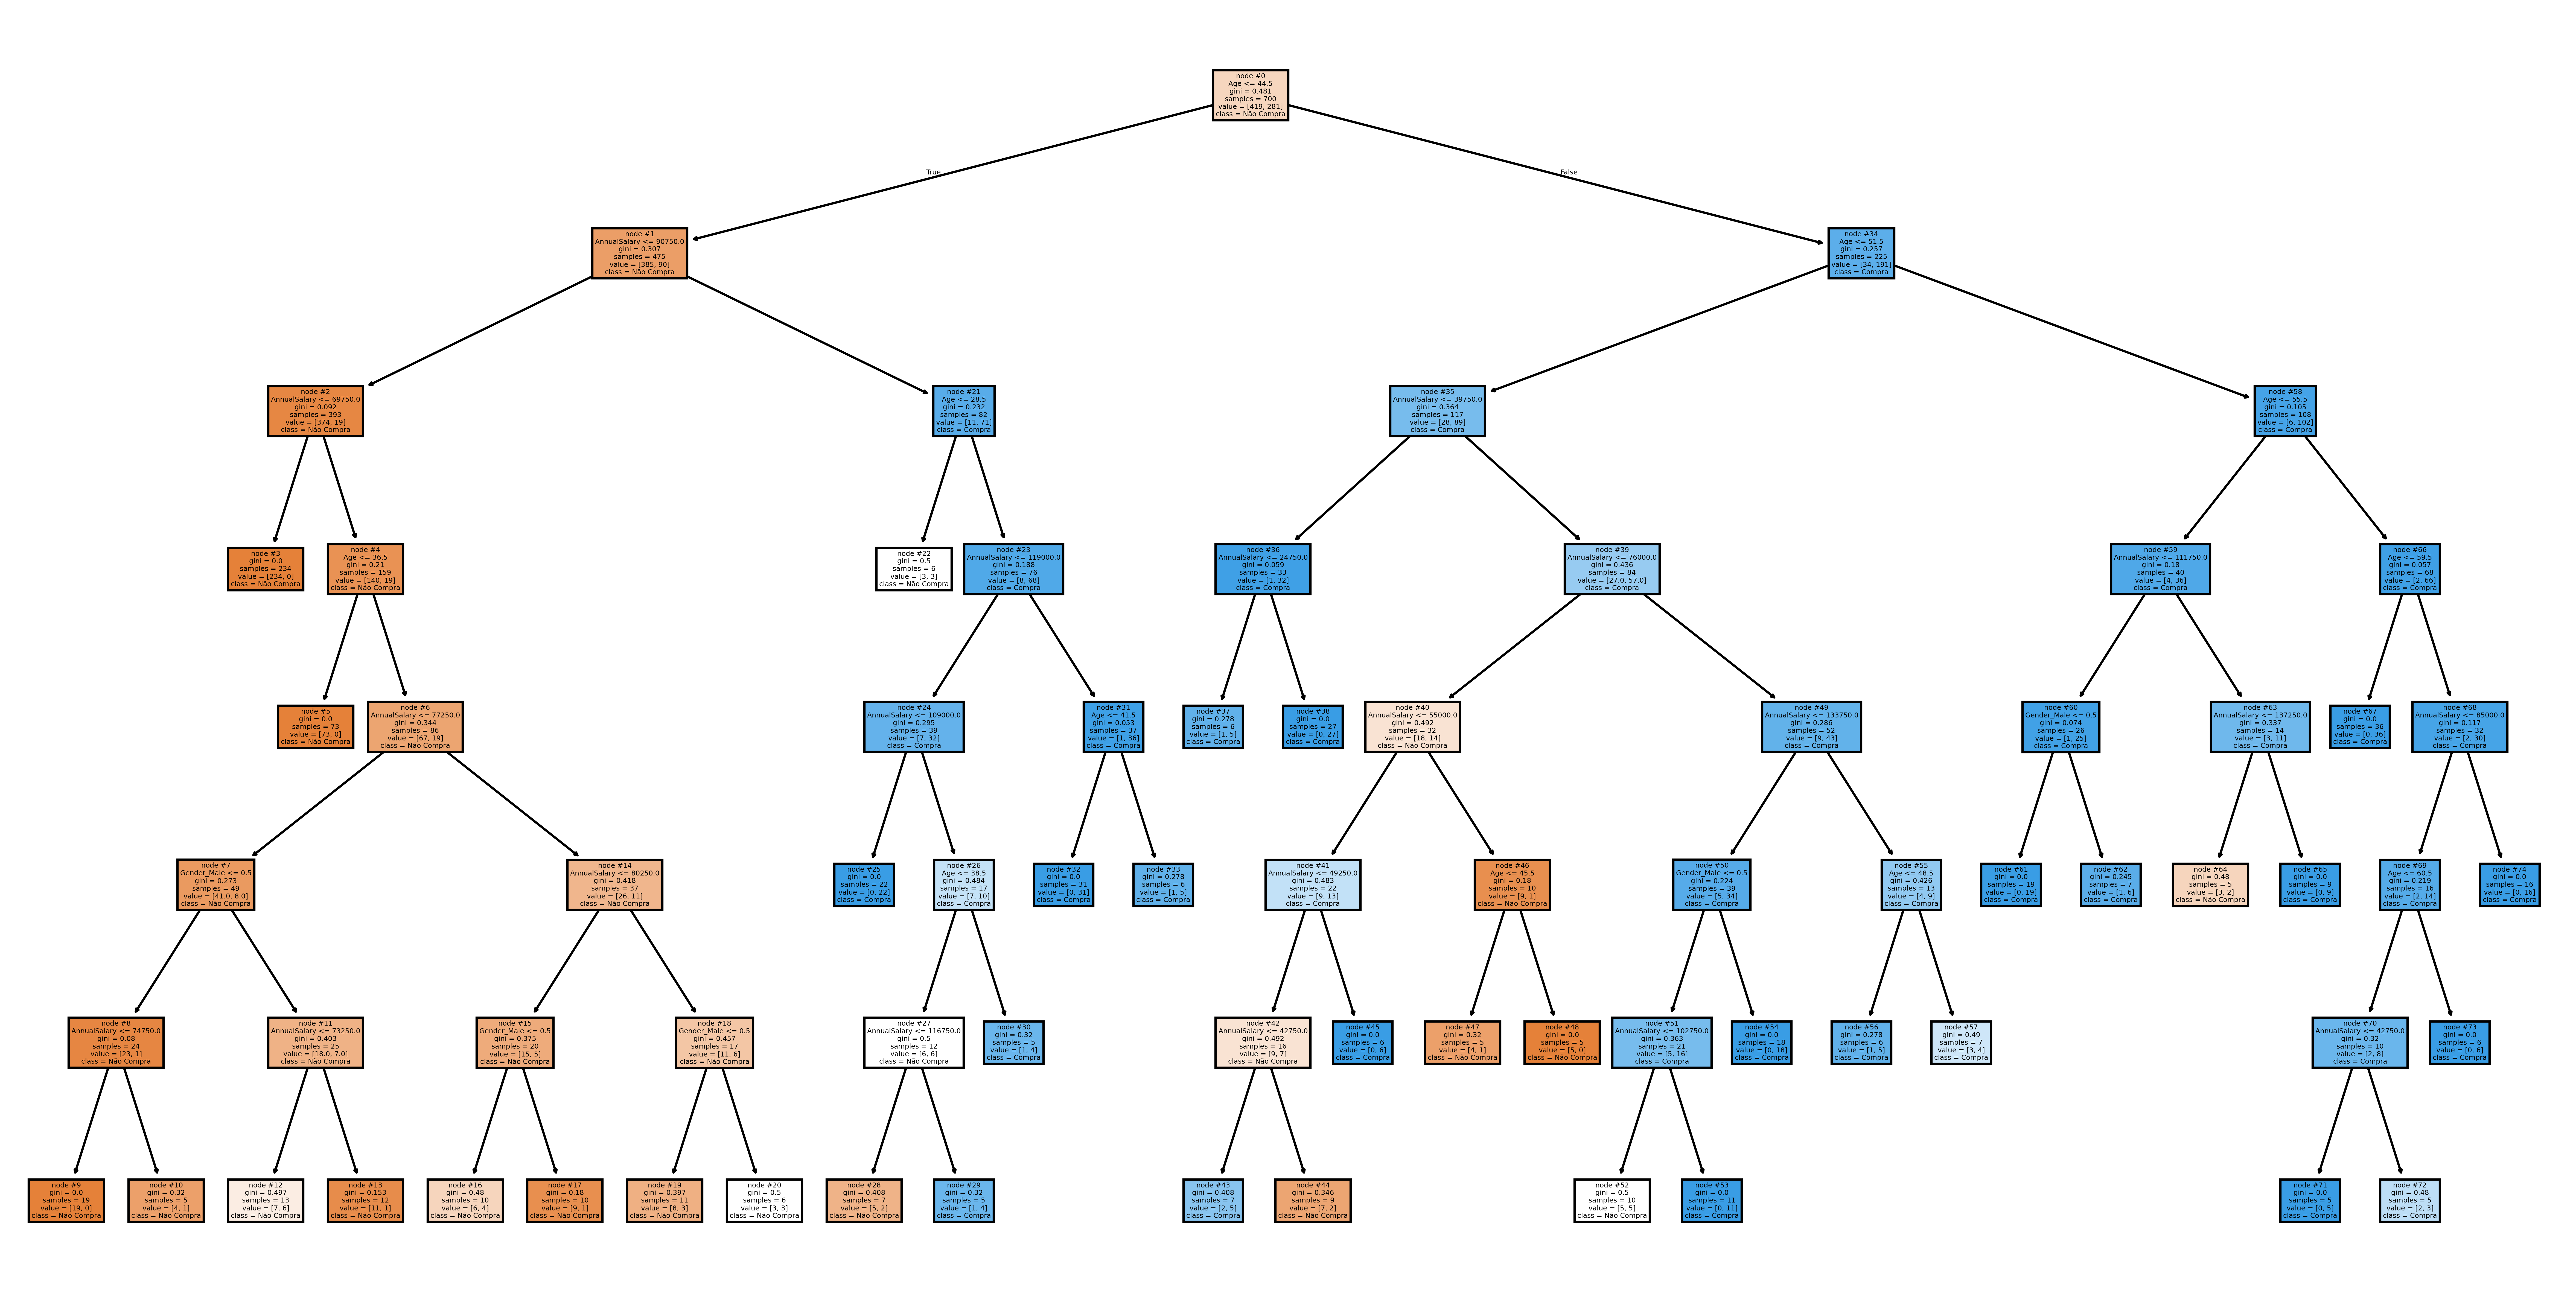

In [25]:
#%% Alguns hiperparâmetros do modelo

# max_depth: profundidade máxima da árvore
# min_samples_split: qtde mínima de observações exigidas para dividir o nó
# min_samples_leaf: qtde mínima de observações exigidas para ser nó folha

tree_clf_aj = DecisionTreeClassifier(max_depth=7,
                                     min_samples_split=10,
                                     min_samples_leaf=5,
                                     random_state=100)
tree_clf_aj.fit(X_train, y_train)

#%% Plotando a árvore ajustada

plt.figure(figsize=(20,10), dpi=600)
plot_tree(tree_clf_aj,
          feature_names=X.columns.tolist(),
          class_names=['Não Compra','Compra'],
          proportion=False,
          filled=True,
          node_ids=True)
plt.show()

In [26]:
#%% Obtendo os valores preditos pelo modelo ajustado (base de teste)

tree_pred_test_class_aj = tree_clf_aj.predict(X_test)
tree_pred_test_prob_aj = tree_clf_aj.predict_proba(X_test)

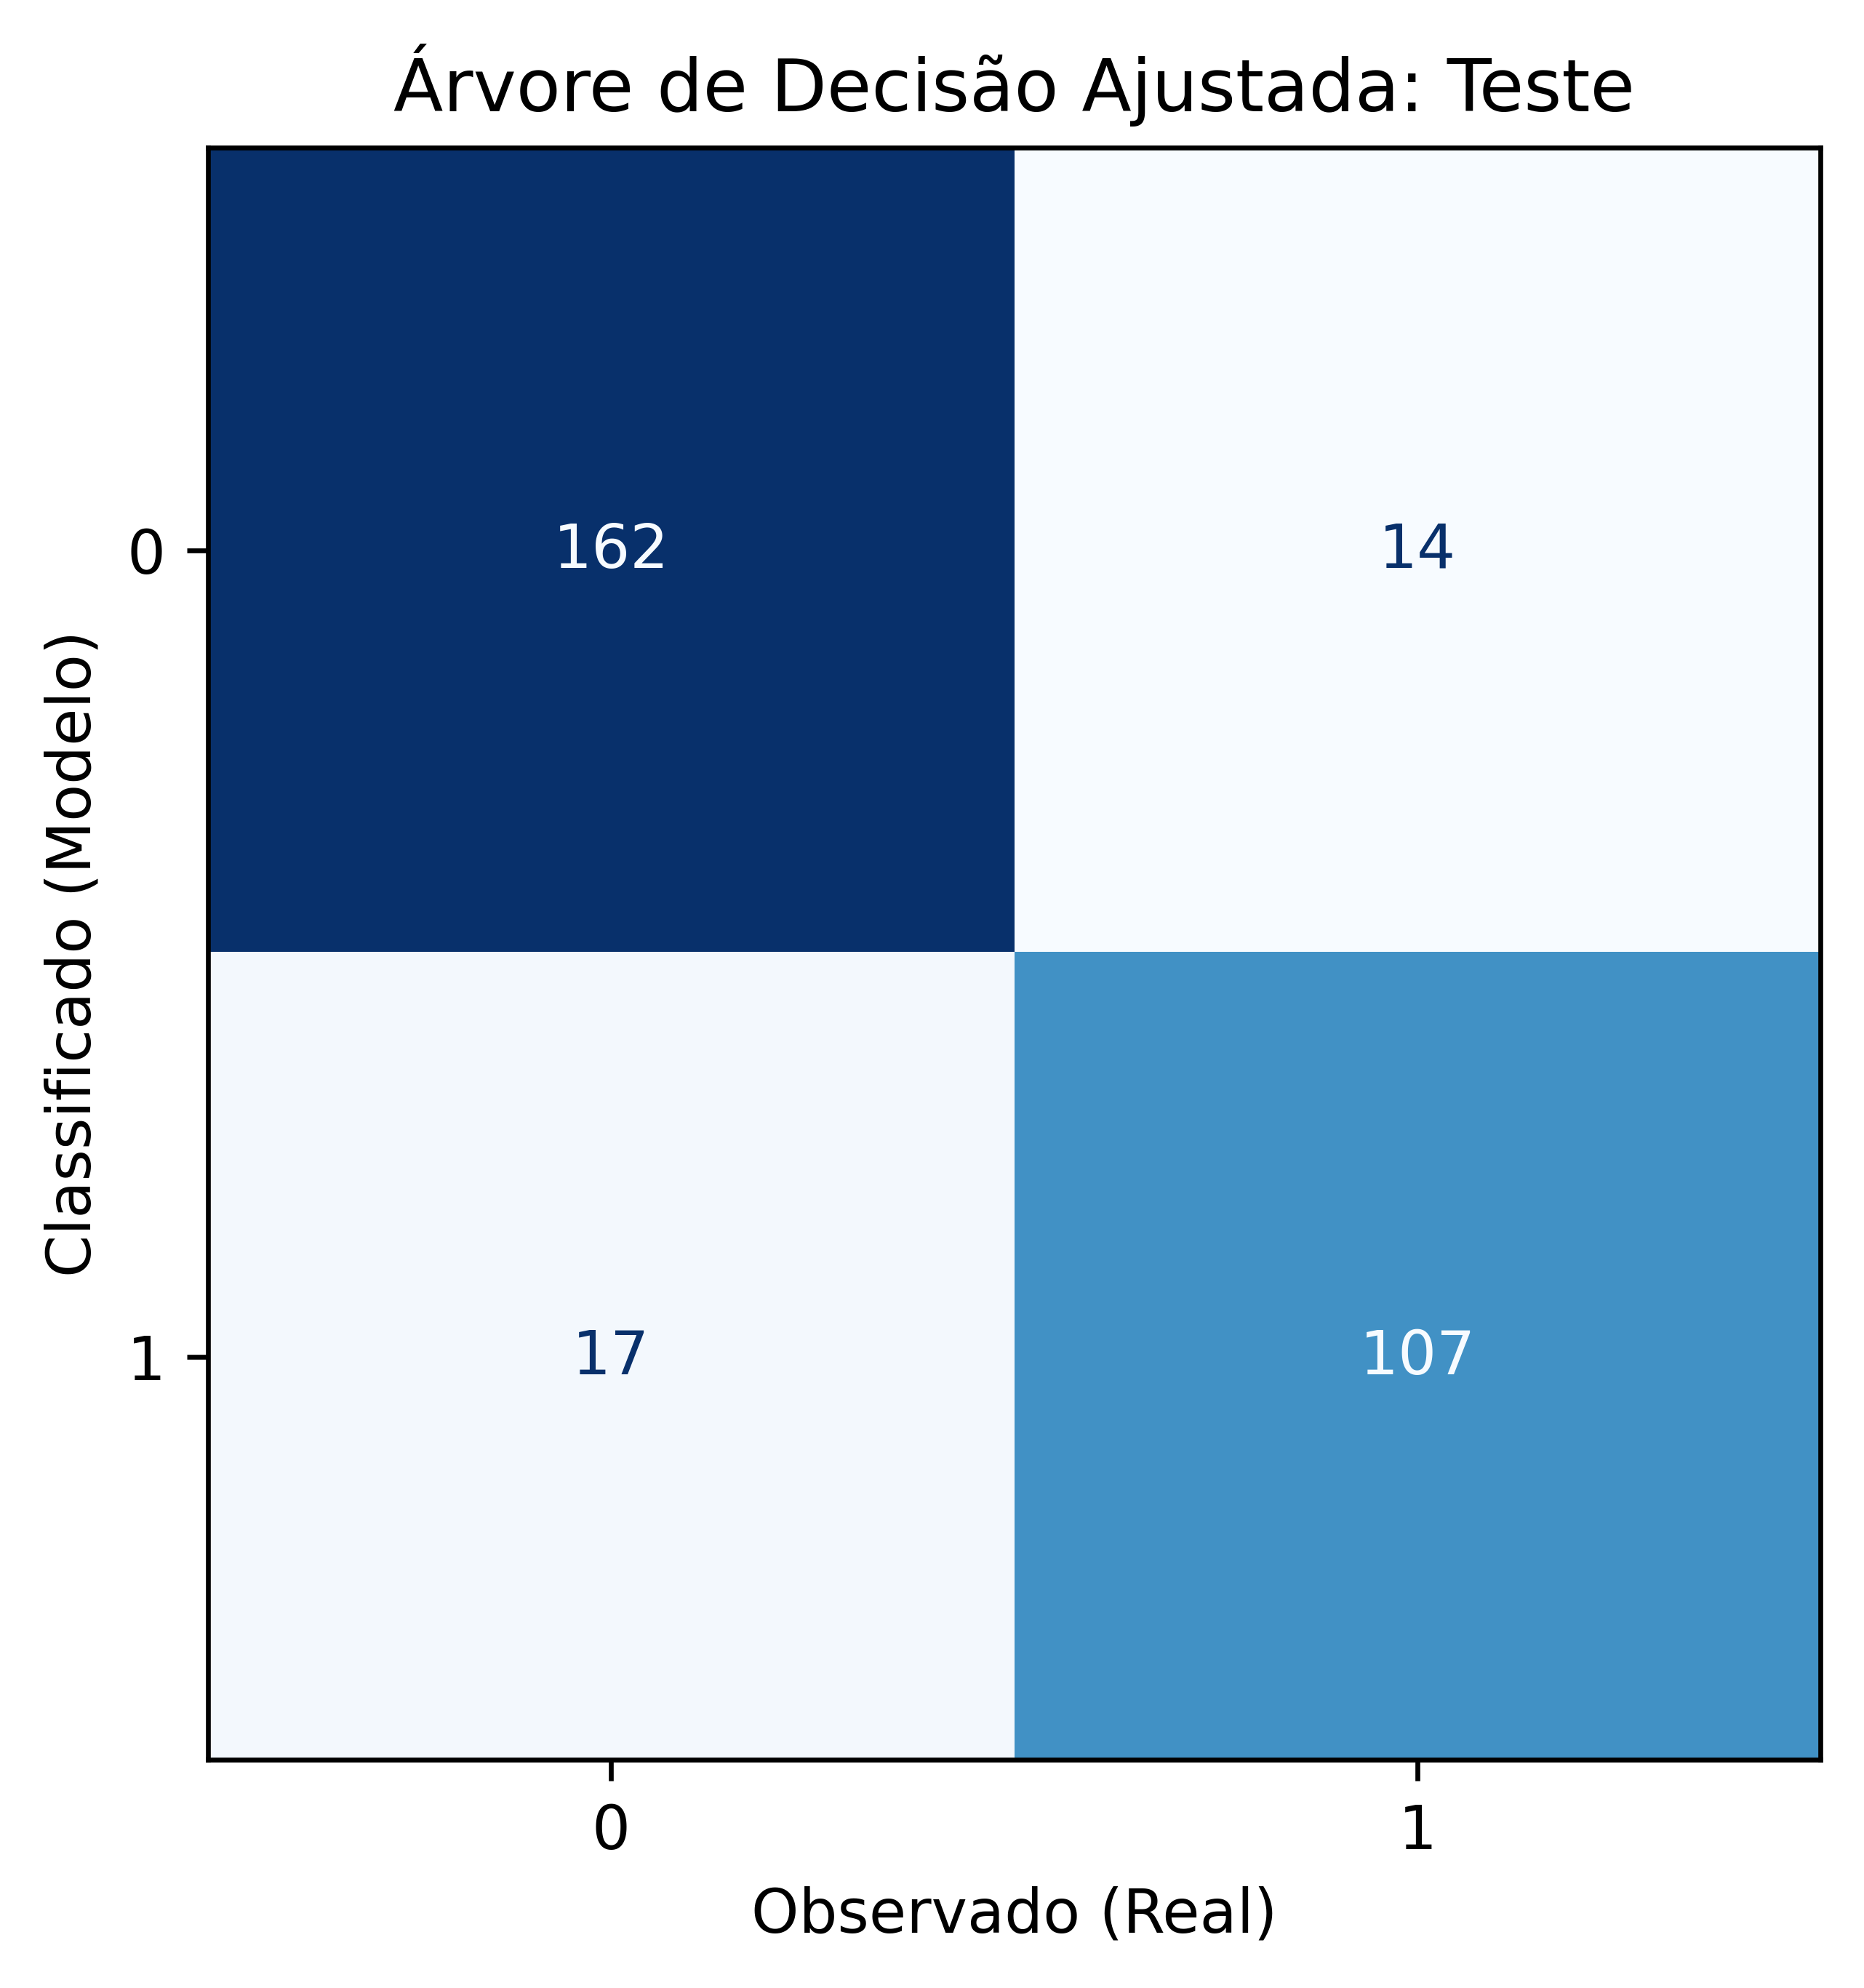

Avaliação da Árvore Ajustada (Base de Teste)
Acurácia: 89.7%
Sensibilidade: 88.4%
Especificidade: 90.5%
Precision: 86.3%


In [27]:
#%% Matriz de confusão (base de teste)

tree_cm_test_aj = confusion_matrix(tree_pred_test_class_aj, y_test)
cm_test_disp_aj = ConfusionMatrixDisplay(tree_cm_test_aj)

plt.rcParams['figure.dpi'] = 600
cm_test_disp_aj.plot(colorbar=False, cmap='Blues')
plt.title('Árvore de Decisão Ajustada: Teste')
plt.xlabel('Observado (Real)')
plt.ylabel('Classificado (Modelo)')
plt.show()

acc_tree_test_aj = accuracy_score(y_test, tree_pred_test_class_aj)
sens_tree_test_aj = recall_score(y_test, tree_pred_test_class_aj, pos_label=1)
espec_tree_test_aj = recall_score(y_test, tree_pred_test_class_aj, pos_label=0)
prec_tree_test_aj = precision_score(y_test, tree_pred_test_class_aj)

print("Avaliação da Árvore Ajustada (Base de Teste)")
print(f"Acurácia: {acc_tree_test_aj:.1%}")
print(f"Sensibilidade: {sens_tree_test_aj:.1%}")
print(f"Especificidade: {espec_tree_test_aj:.1%}")
print(f"Precision: {prec_tree_test_aj:.1%}")

## Não há melhoria expressiva em relação à árvore menor!

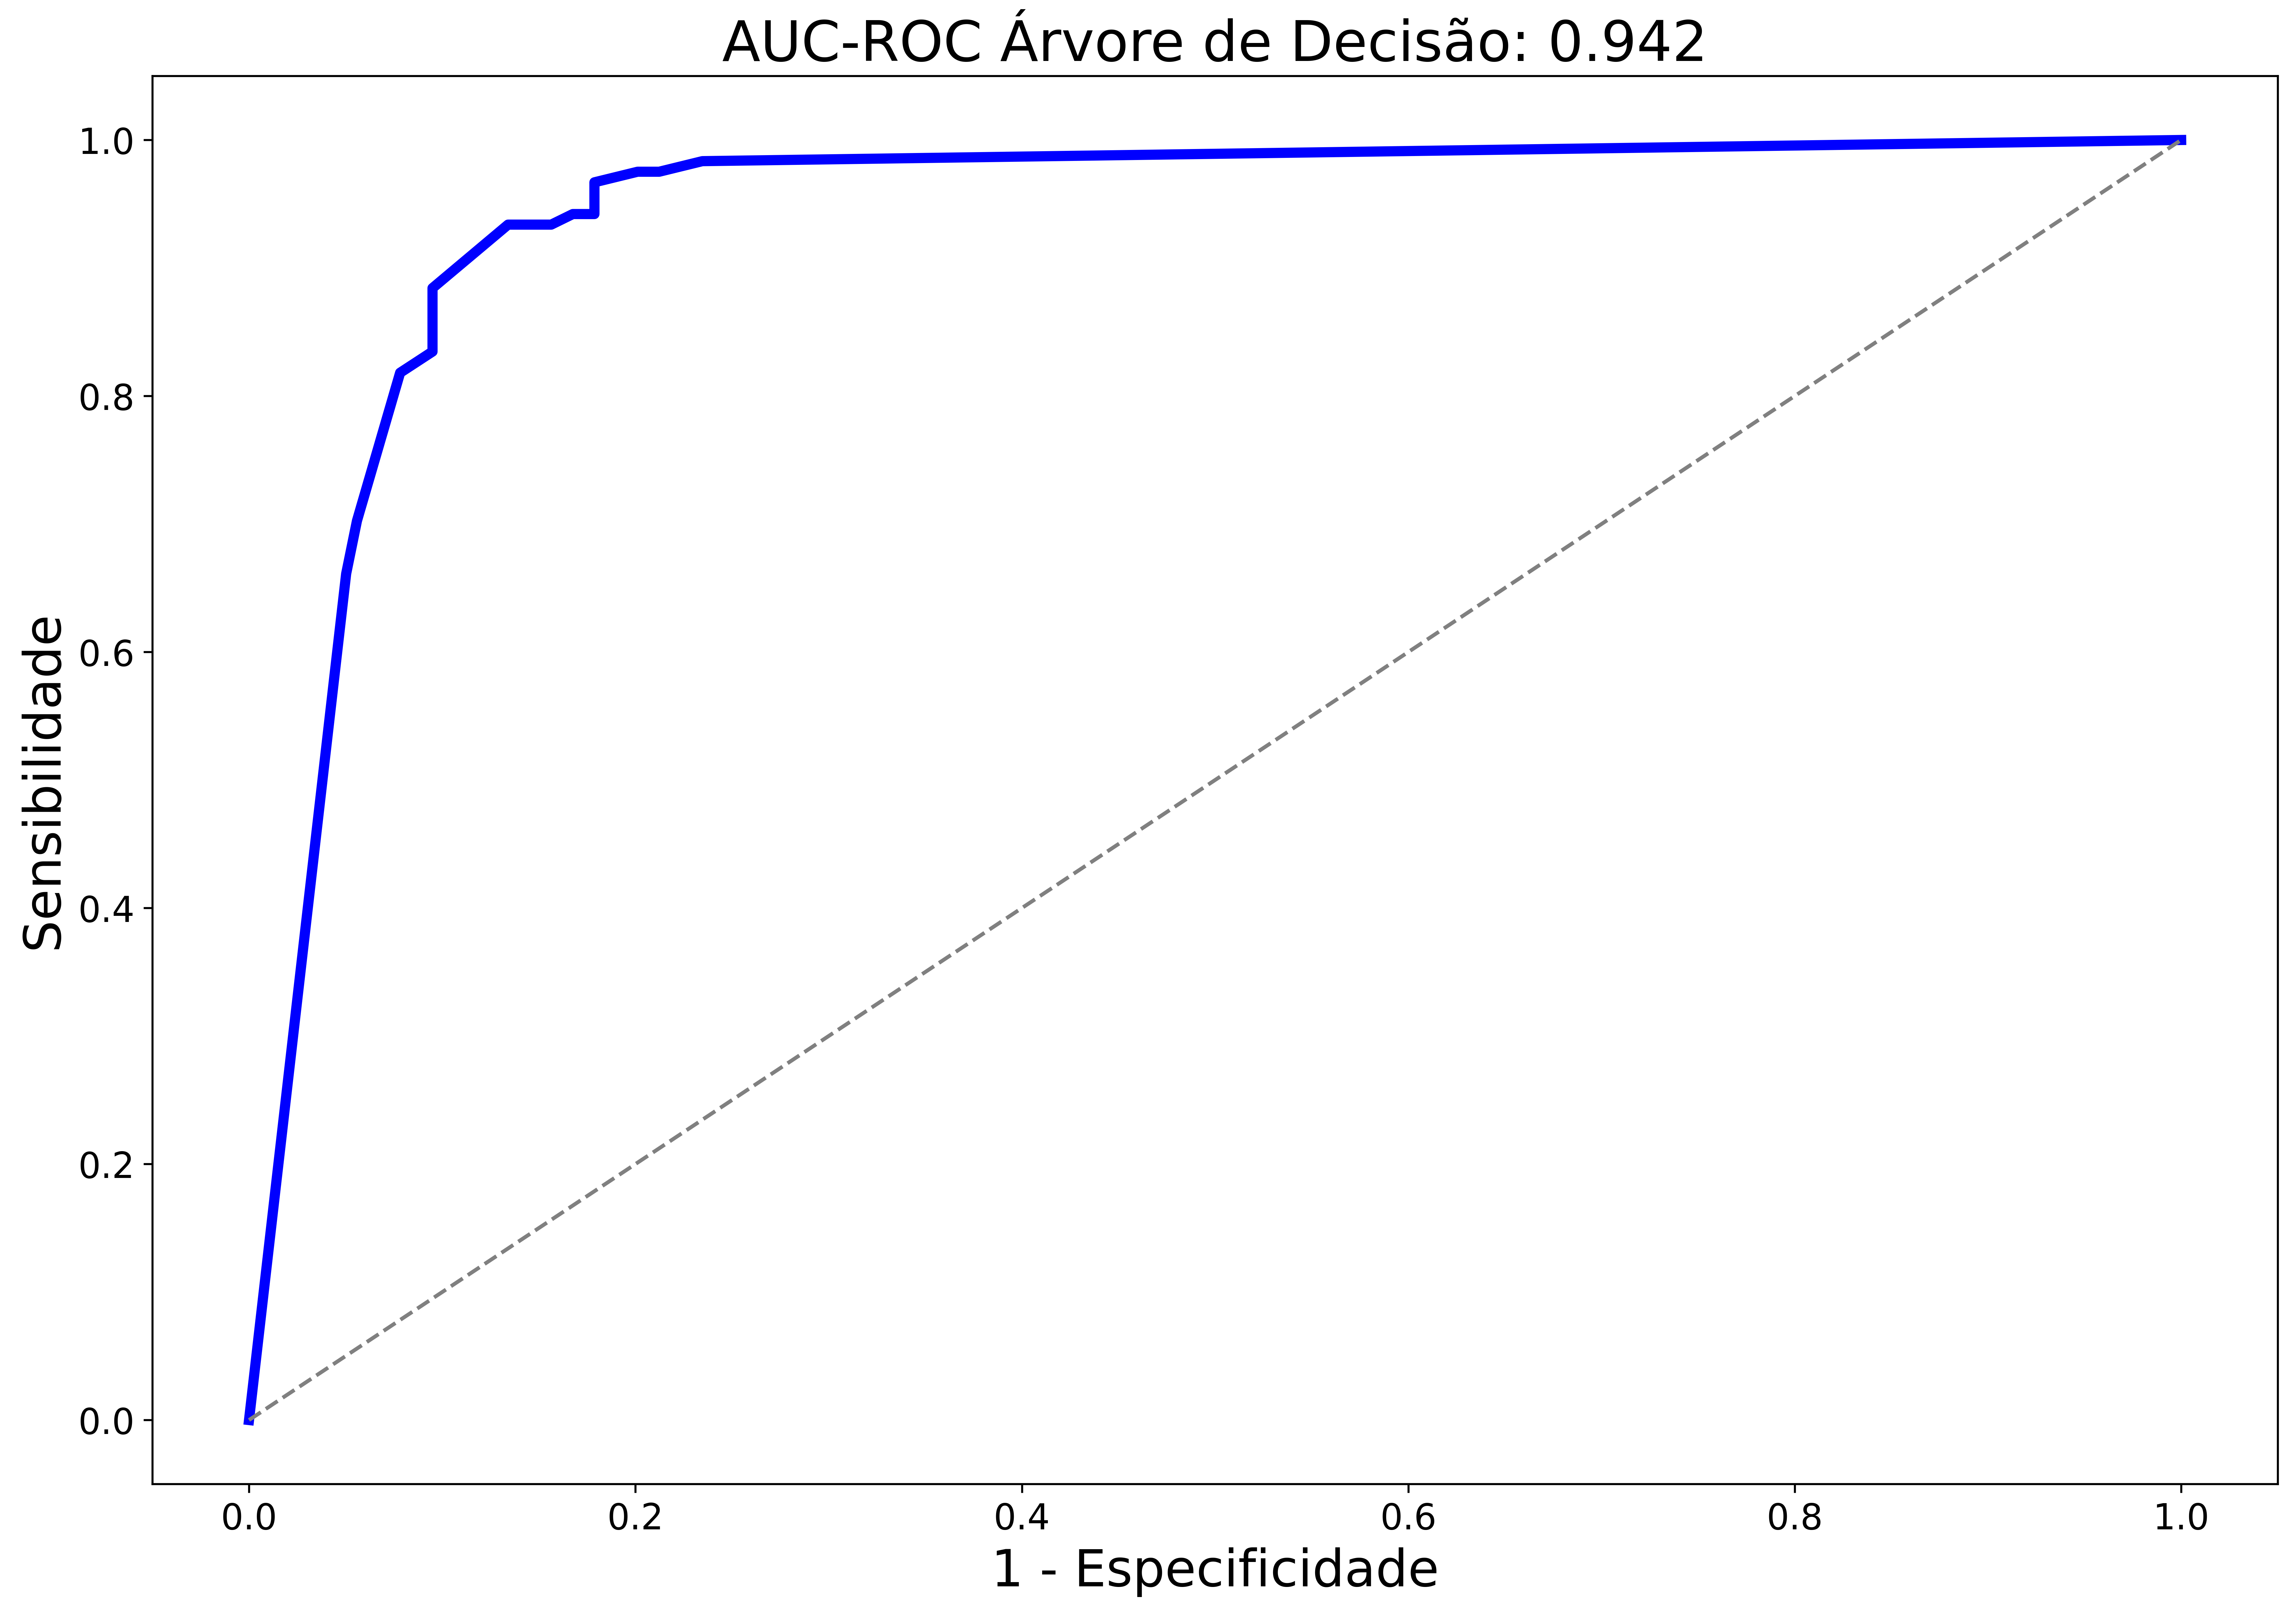

In [28]:
#%% Curva ROC (base de teste)

# Parametrizando a função da curva ROC (real vs. previsto)
fpr_tree, tpr_tree, thresholds_tree = roc_curve(y_test, tree_pred_test_prob_aj[:,1])
roc_auc_tree = auc(fpr_tree, tpr_tree)

# Plotando a curva ROC
plt.figure(figsize=(15,10), dpi=600)
plt.plot(fpr_tree, tpr_tree, color='blue', linewidth=4)
plt.plot(fpr_tree, fpr_tree, color='gray', linestyle='dashed')
plt.title('AUC-ROC Árvore de Decisão: %g' % round(roc_auc_tree, 3), fontsize=22)
plt.xlabel('1 - Especificidade', fontsize=20)
plt.ylabel('Sensibilidade', fontsize=20)
plt.xticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.show()

In [29]:
#%%######################### Random Forest ####################################
###############################################################################
#%% Estimando uma random forest

rf_clf = RandomForestClassifier(n_estimators=50, 
                                max_depth=2,
                                max_features=3,
                                random_state=100)
rf_clf.fit(X_train, y_train)

## Alguns hiperparâmetros:

# n_estimators: qtde de árvores estimadas
# max_depth: profundidade máxima das árvores
# max_features: qtde de variáveis preditoras consideradas nos splits
# min_samples_split: qtde mínima de observações exigidas para dividir o nó
# min_samples_leaf: qtde mínima de observações exigidas para ser nó folha

RandomForestClassifier(max_depth=2, max_features=3, n_estimators=50,
                       random_state=100)

In [30]:
#%% Obtendo os valores preditos pela RF

# Predict na base de treinamento
rf_pred_train_class = rf_clf.predict(X_train)
rf_pred_train_prob = rf_clf.predict_proba(X_train)

# Predict na base de testes
rf_pred_test_class = rf_clf.predict(X_test)
rf_pred_test_prob = rf_clf.predict_proba(X_test)

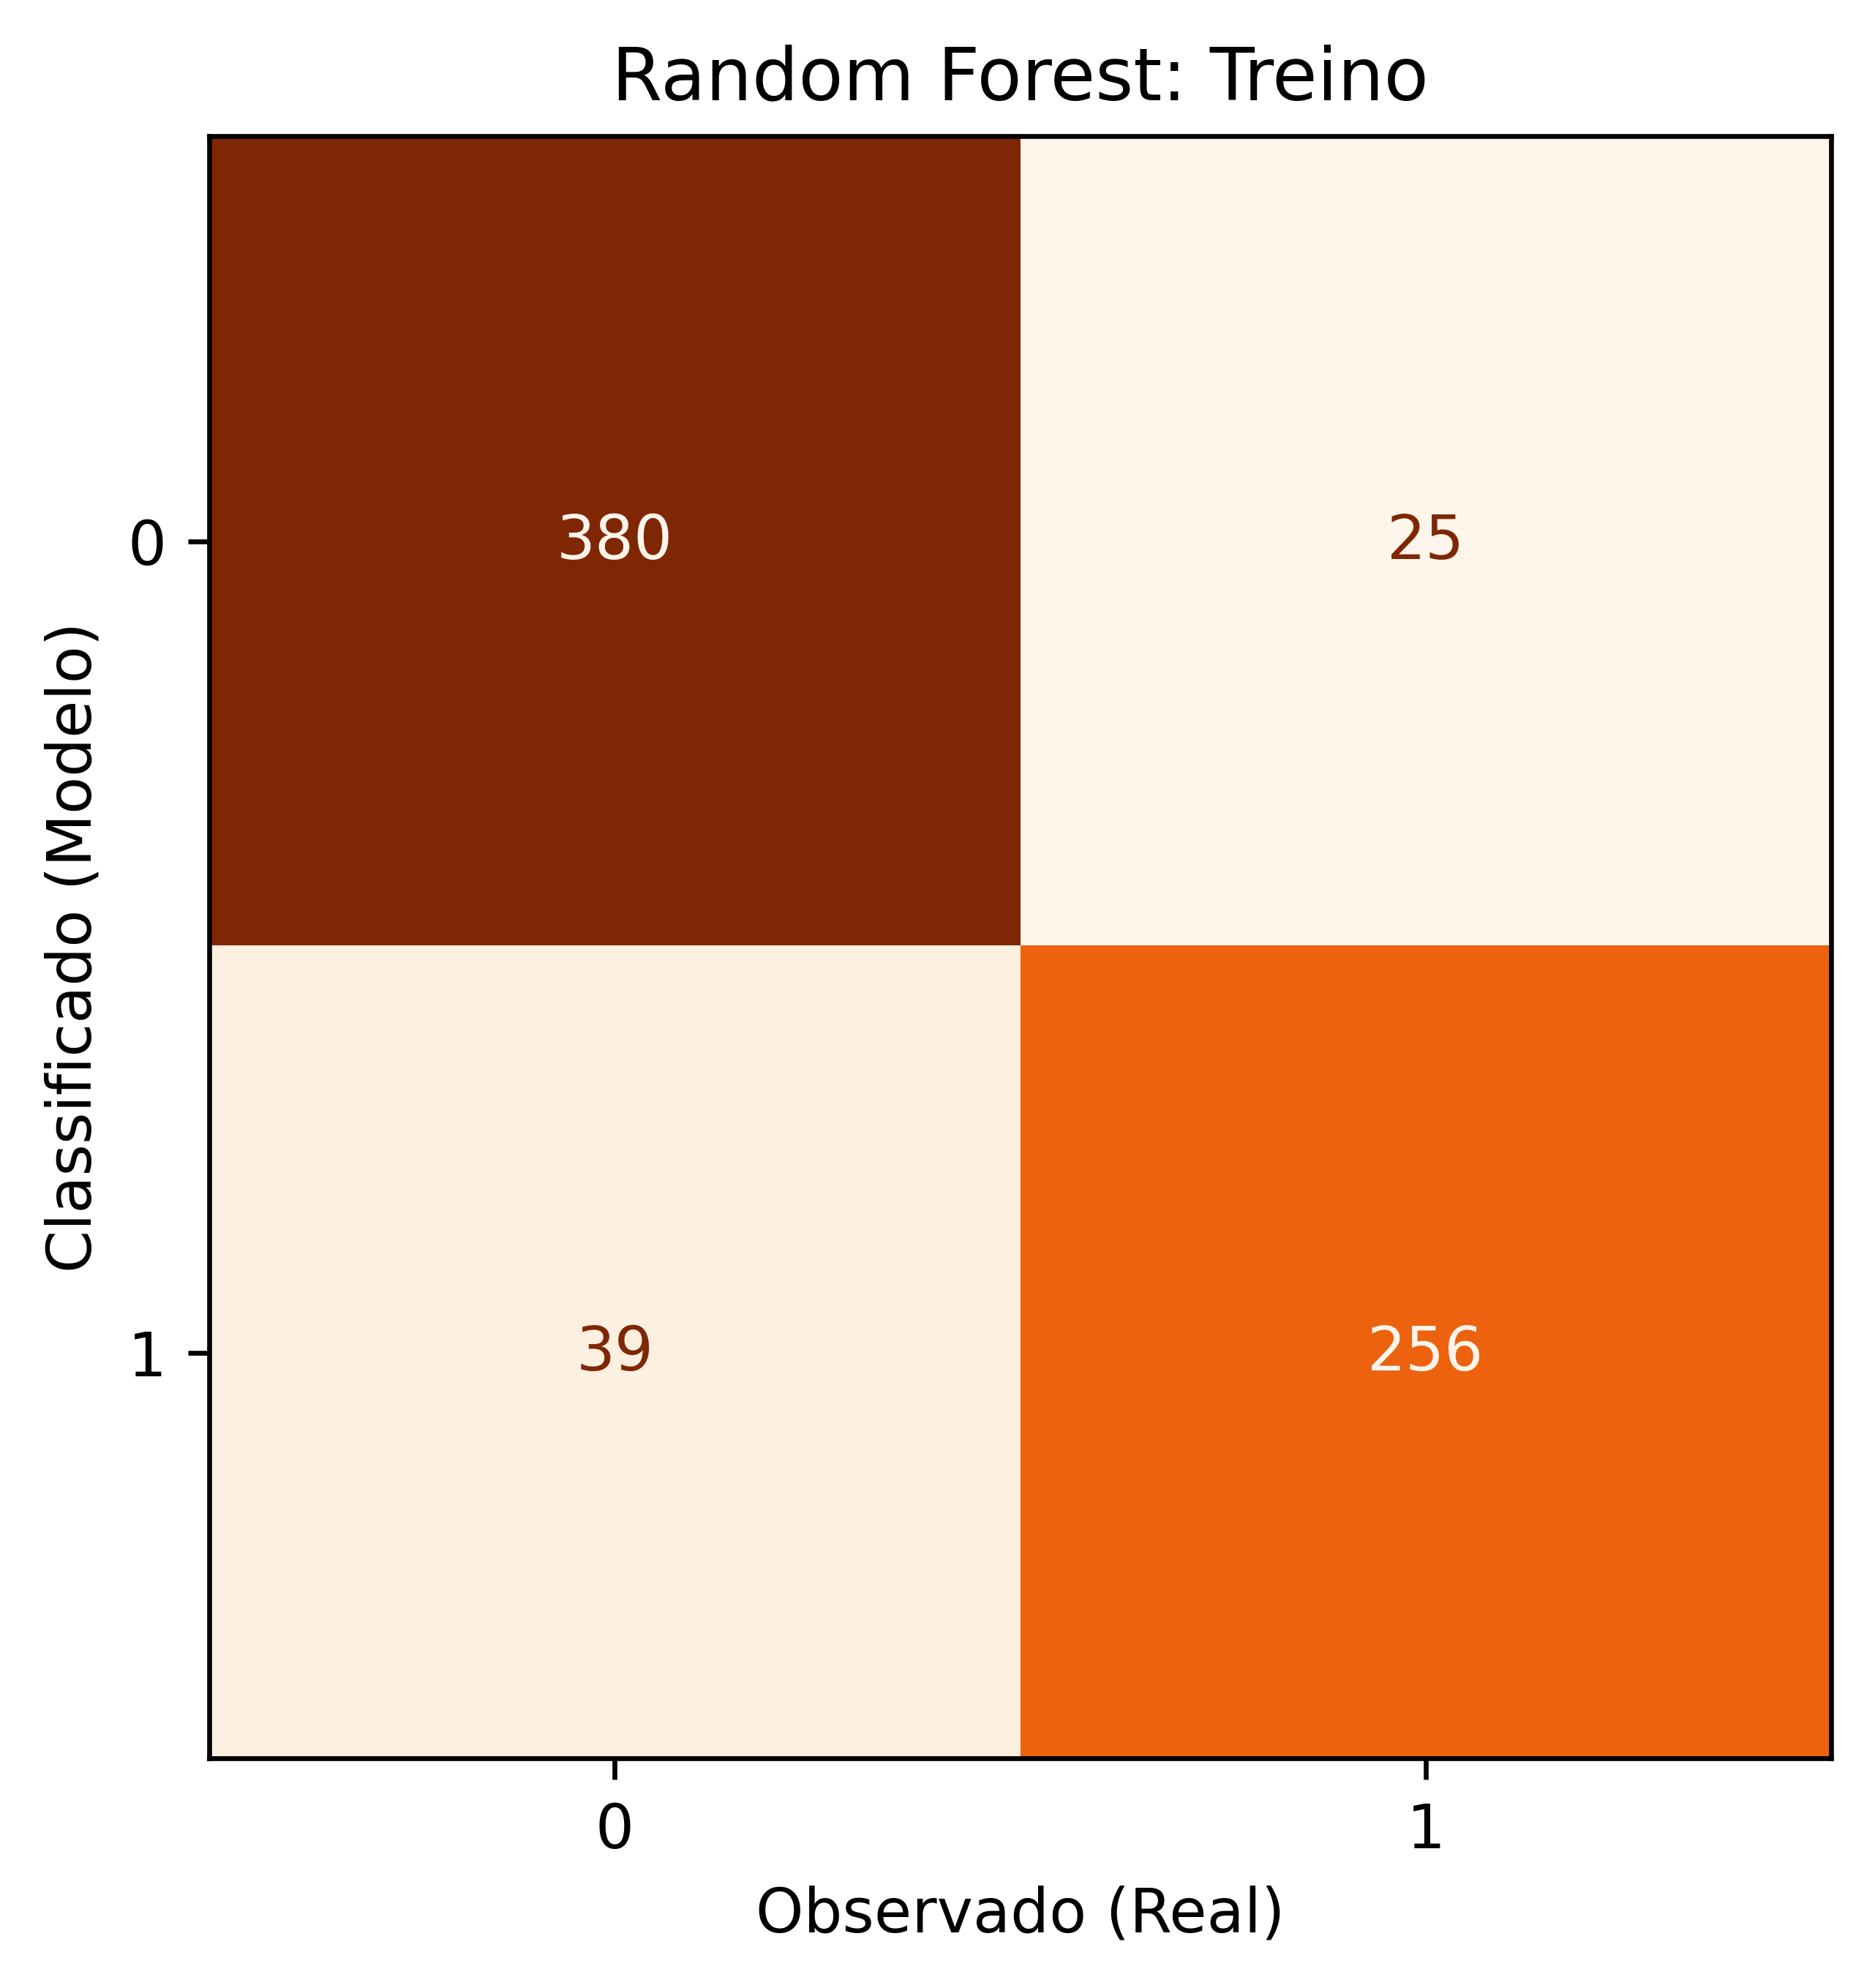

Avaliação da RF (Base de Treino)
Acurácia: 90.9%
Sensibilidade: 91.1%
Especificidade: 90.7%
Precision: 86.8%


In [31]:
#%% Matriz de confusão (base de treino)

rf_cm_train = confusion_matrix(rf_pred_train_class, y_train)
cm_rf_train = ConfusionMatrixDisplay(rf_cm_train)

plt.rcParams['figure.dpi'] = 600
cm_rf_train.plot(colorbar=False, cmap='Oranges')
plt.title('Random Forest: Treino')
plt.xlabel('Observado (Real)')
plt.ylabel('Classificado (Modelo)')
plt.show()

acc_rf_train = accuracy_score(y_train, rf_pred_train_class)
sens_rf_train = recall_score(y_train, rf_pred_train_class, pos_label=1)
espec_rf_train = recall_score(y_train, rf_pred_train_class, pos_label=0)
prec_rf_train = precision_score(y_train, rf_pred_train_class)

print("Avaliação da RF (Base de Treino)")
print(f"Acurácia: {acc_rf_train:.1%}")
print(f"Sensibilidade: {sens_rf_train:.1%}")
print(f"Especificidade: {espec_rf_train:.1%}")
print(f"Precision: {prec_rf_train:.1%}")

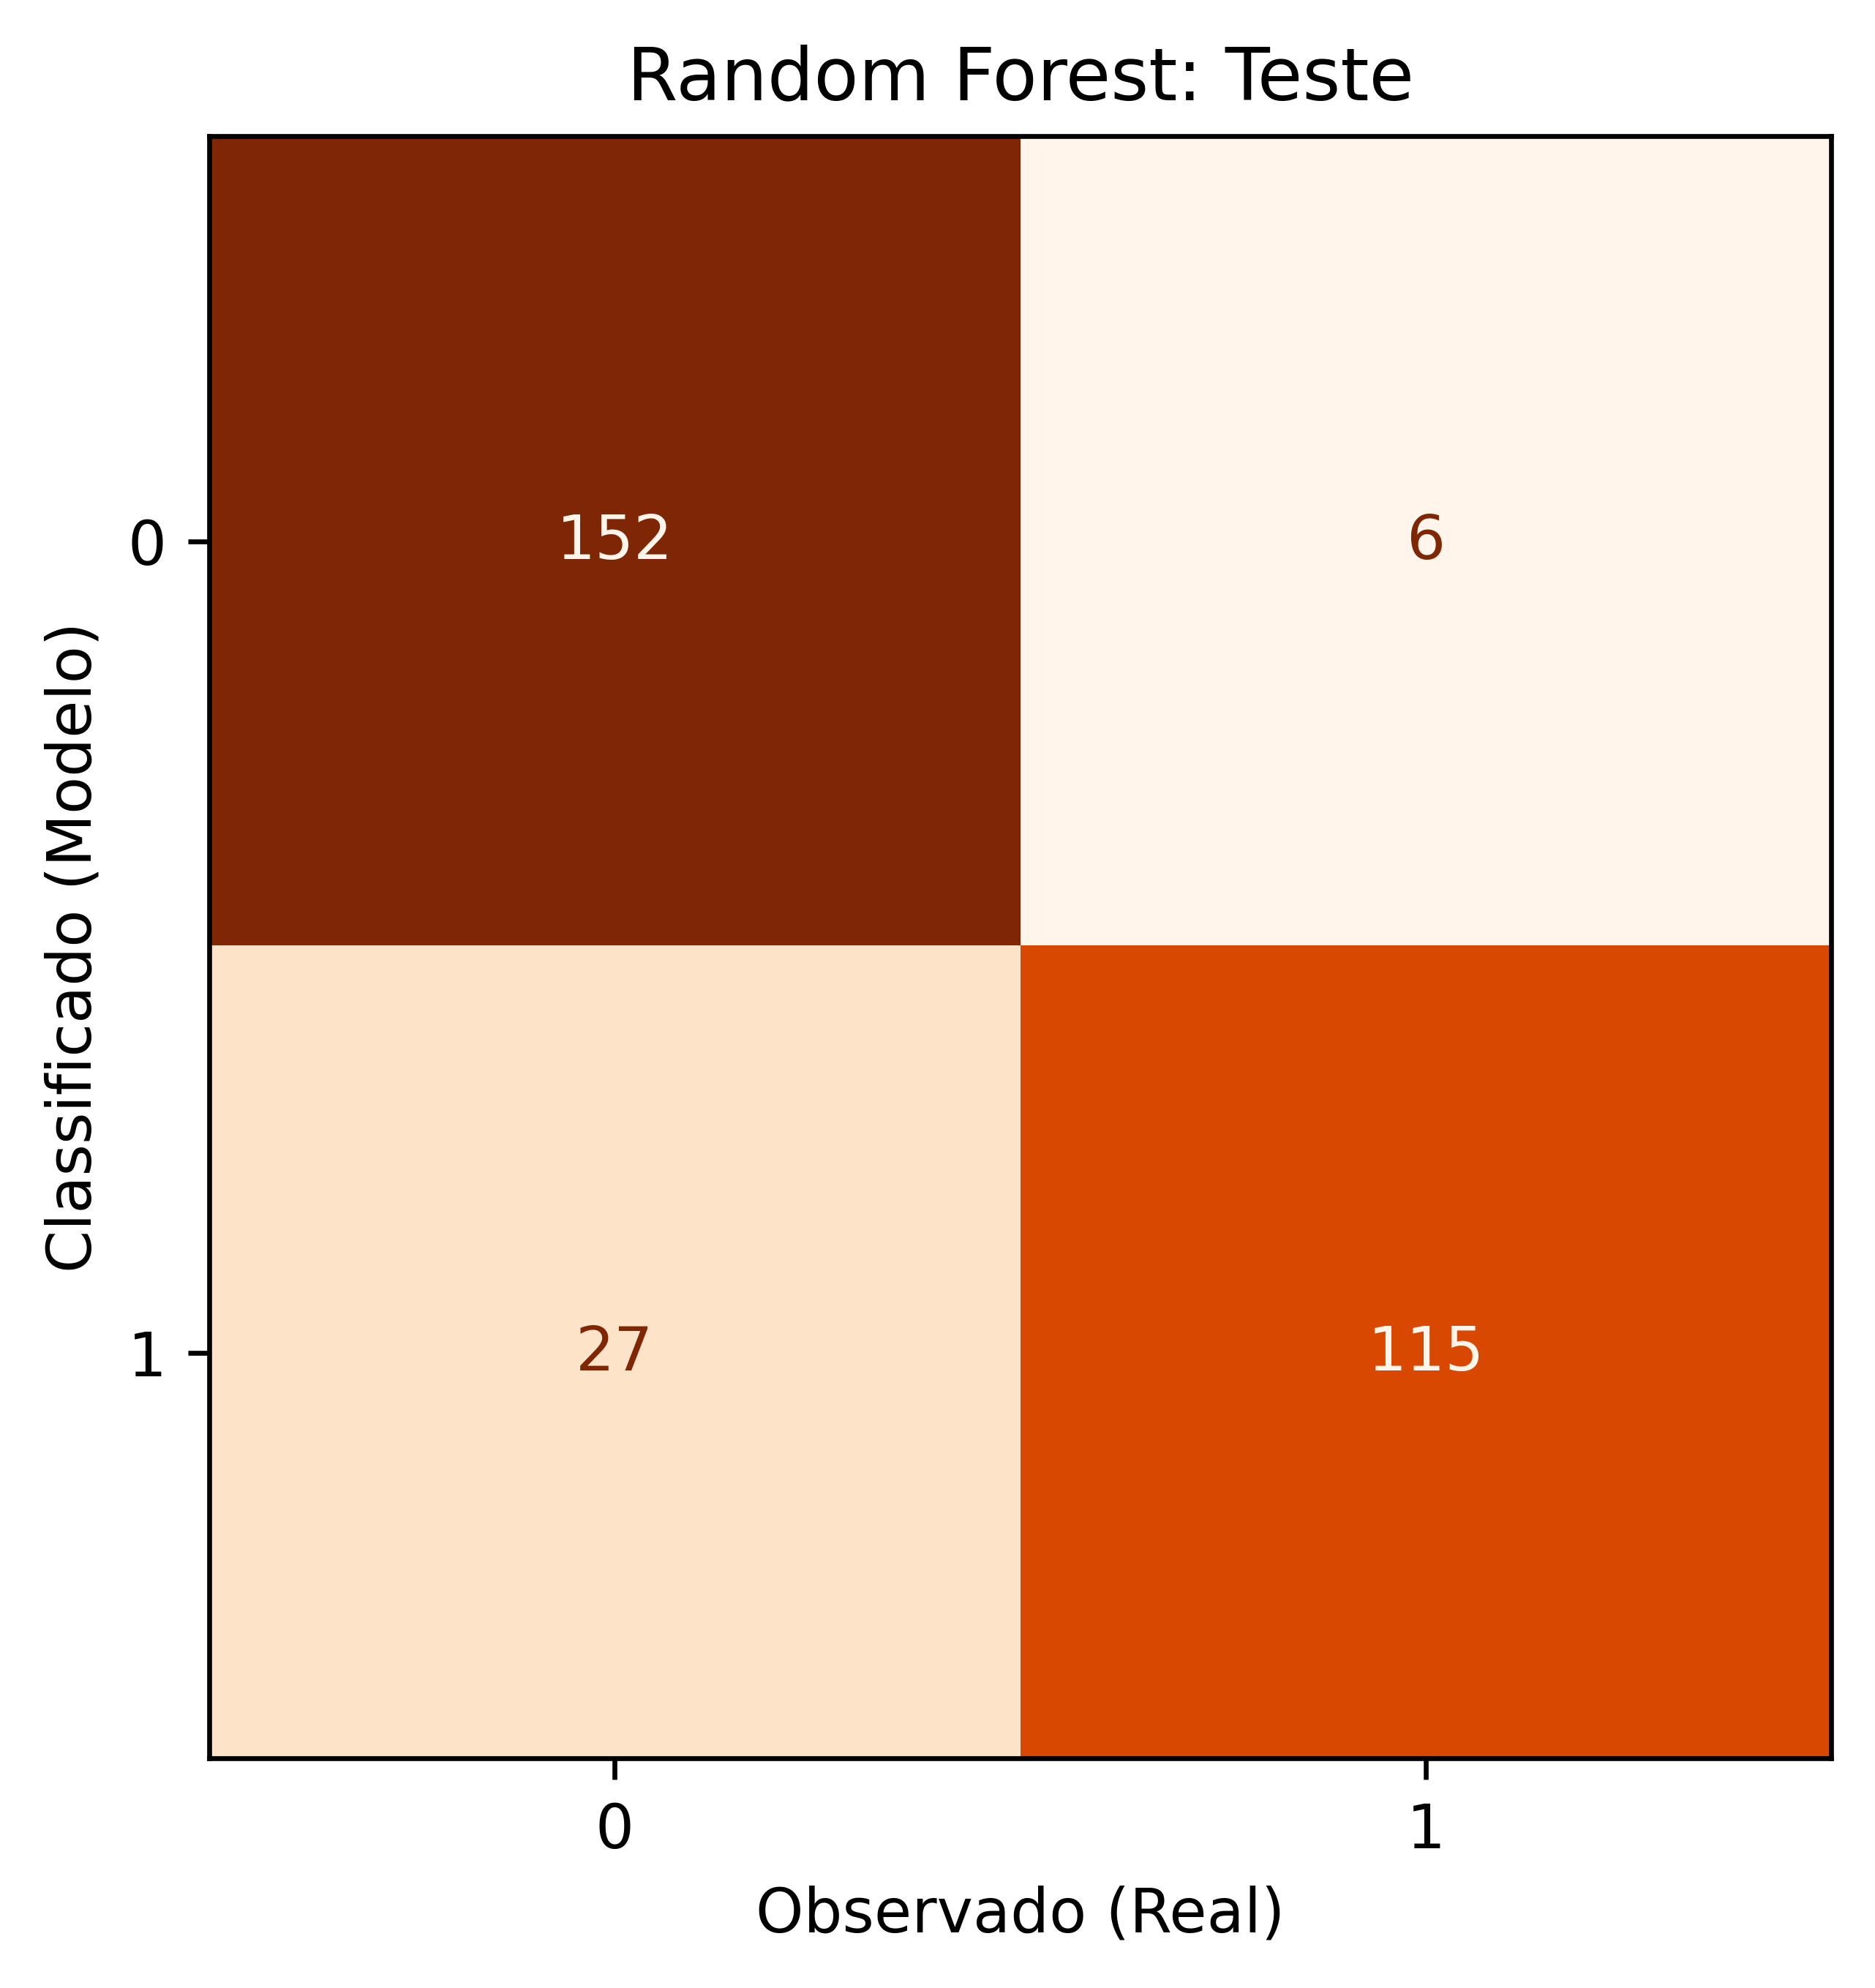

Avaliação da RF (Base de Teste)
Acurácia: 89.0%
Sensibilidade: 95.0%
Especificidade: 84.9%
Precision: 81.0%


In [32]:
#%% Matriz de confusão (base de teste)

rf_cm_test = confusion_matrix(rf_pred_test_class, y_test)
cm_rf_test = ConfusionMatrixDisplay(rf_cm_test)

plt.rcParams['figure.dpi'] = 600
cm_rf_test.plot(colorbar=False, cmap='Oranges')
plt.title('Random Forest: Teste')
plt.xlabel('Observado (Real)')
plt.ylabel('Classificado (Modelo)')
plt.show()

acc_rf_test = accuracy_score(y_test, rf_pred_test_class)
sens_rf_test = recall_score(y_test, rf_pred_test_class, pos_label=1)
espec_rf_test = recall_score(y_test, rf_pred_test_class, pos_label=0)
prec_rf_test = precision_score(y_test, rf_pred_test_class)

print("Avaliação da RF (Base de Teste)")
print(f"Acurácia: {acc_rf_test:.1%}")
print(f"Sensibilidade: {sens_rf_test:.1%}")
print(f"Especificidade: {espec_rf_test:.1%}")
print(f"Precision: {prec_rf_test:.1%}")

In [33]:
#%% Grid Search

# Vamos especificar a lista de hiperparâmetros desejados e seus valores
param_grid_rf = {
    'n_estimators': [500, 1000],
    'max_depth': [5, 7],
    'max_features': [2, 3],
    'min_samples_split': [20, 50]
}

# Identificar o algoritmo em uso
rf_grid = RandomForestClassifier(random_state=100)

# Treinar os modelos para o grid search
rf_grid_model = GridSearchCV(estimator = rf_grid, 
                             param_grid = param_grid_rf,
                             scoring='accuracy',
                             cv=5, verbose=2)

rf_grid_model.fit(X_train, y_train)

# Verificando os melhores parâmetros obtidos
rf_grid_model.best_params_

# Gerando o modelo com os melhores hiperparâmetros
rf_best = rf_grid_model.best_estimator_

# Predict na base de treino
rf_grid_pred_train_class = rf_best.predict(X_train)
rf_grid_pred_train_prob = rf_best.predict_proba(X_train)

# Predict na base de testes
rf_grid_pred_test_class = rf_best.predict(X_test)
rf_grid_pred_test_prob = rf_best.predict_proba(X_test)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END max_depth=5, max_features=2, min_samples_split=20, n_estimators=500; total time=   0.9s
[CV] END max_depth=5, max_features=2, min_samples_split=20, n_estimators=500; total time=   0.9s
[CV] END max_depth=5, max_features=2, min_samples_split=20, n_estimators=500; total time=   0.7s
[CV] END max_depth=5, max_features=2, min_samples_split=20, n_estimators=500; total time=   0.7s
[CV] END max_depth=5, max_features=2, min_samples_split=20, n_estimators=500; total time=   0.6s
[CV] END max_depth=5, max_features=2, min_samples_split=20, n_estimators=1000; total time=   1.7s
[CV] END max_depth=5, max_features=2, min_samples_split=20, n_estimators=1000; total time=   1.5s
[CV] END max_depth=5, max_features=2, min_samples_split=20, n_estimators=1000; total time=   1.3s
[CV] END max_depth=5, max_features=2, min_samples_split=20, n_estimators=1000; total time=   1.5s
[CV] END max_depth=5, max_features=2, min_samples_split=20, n_

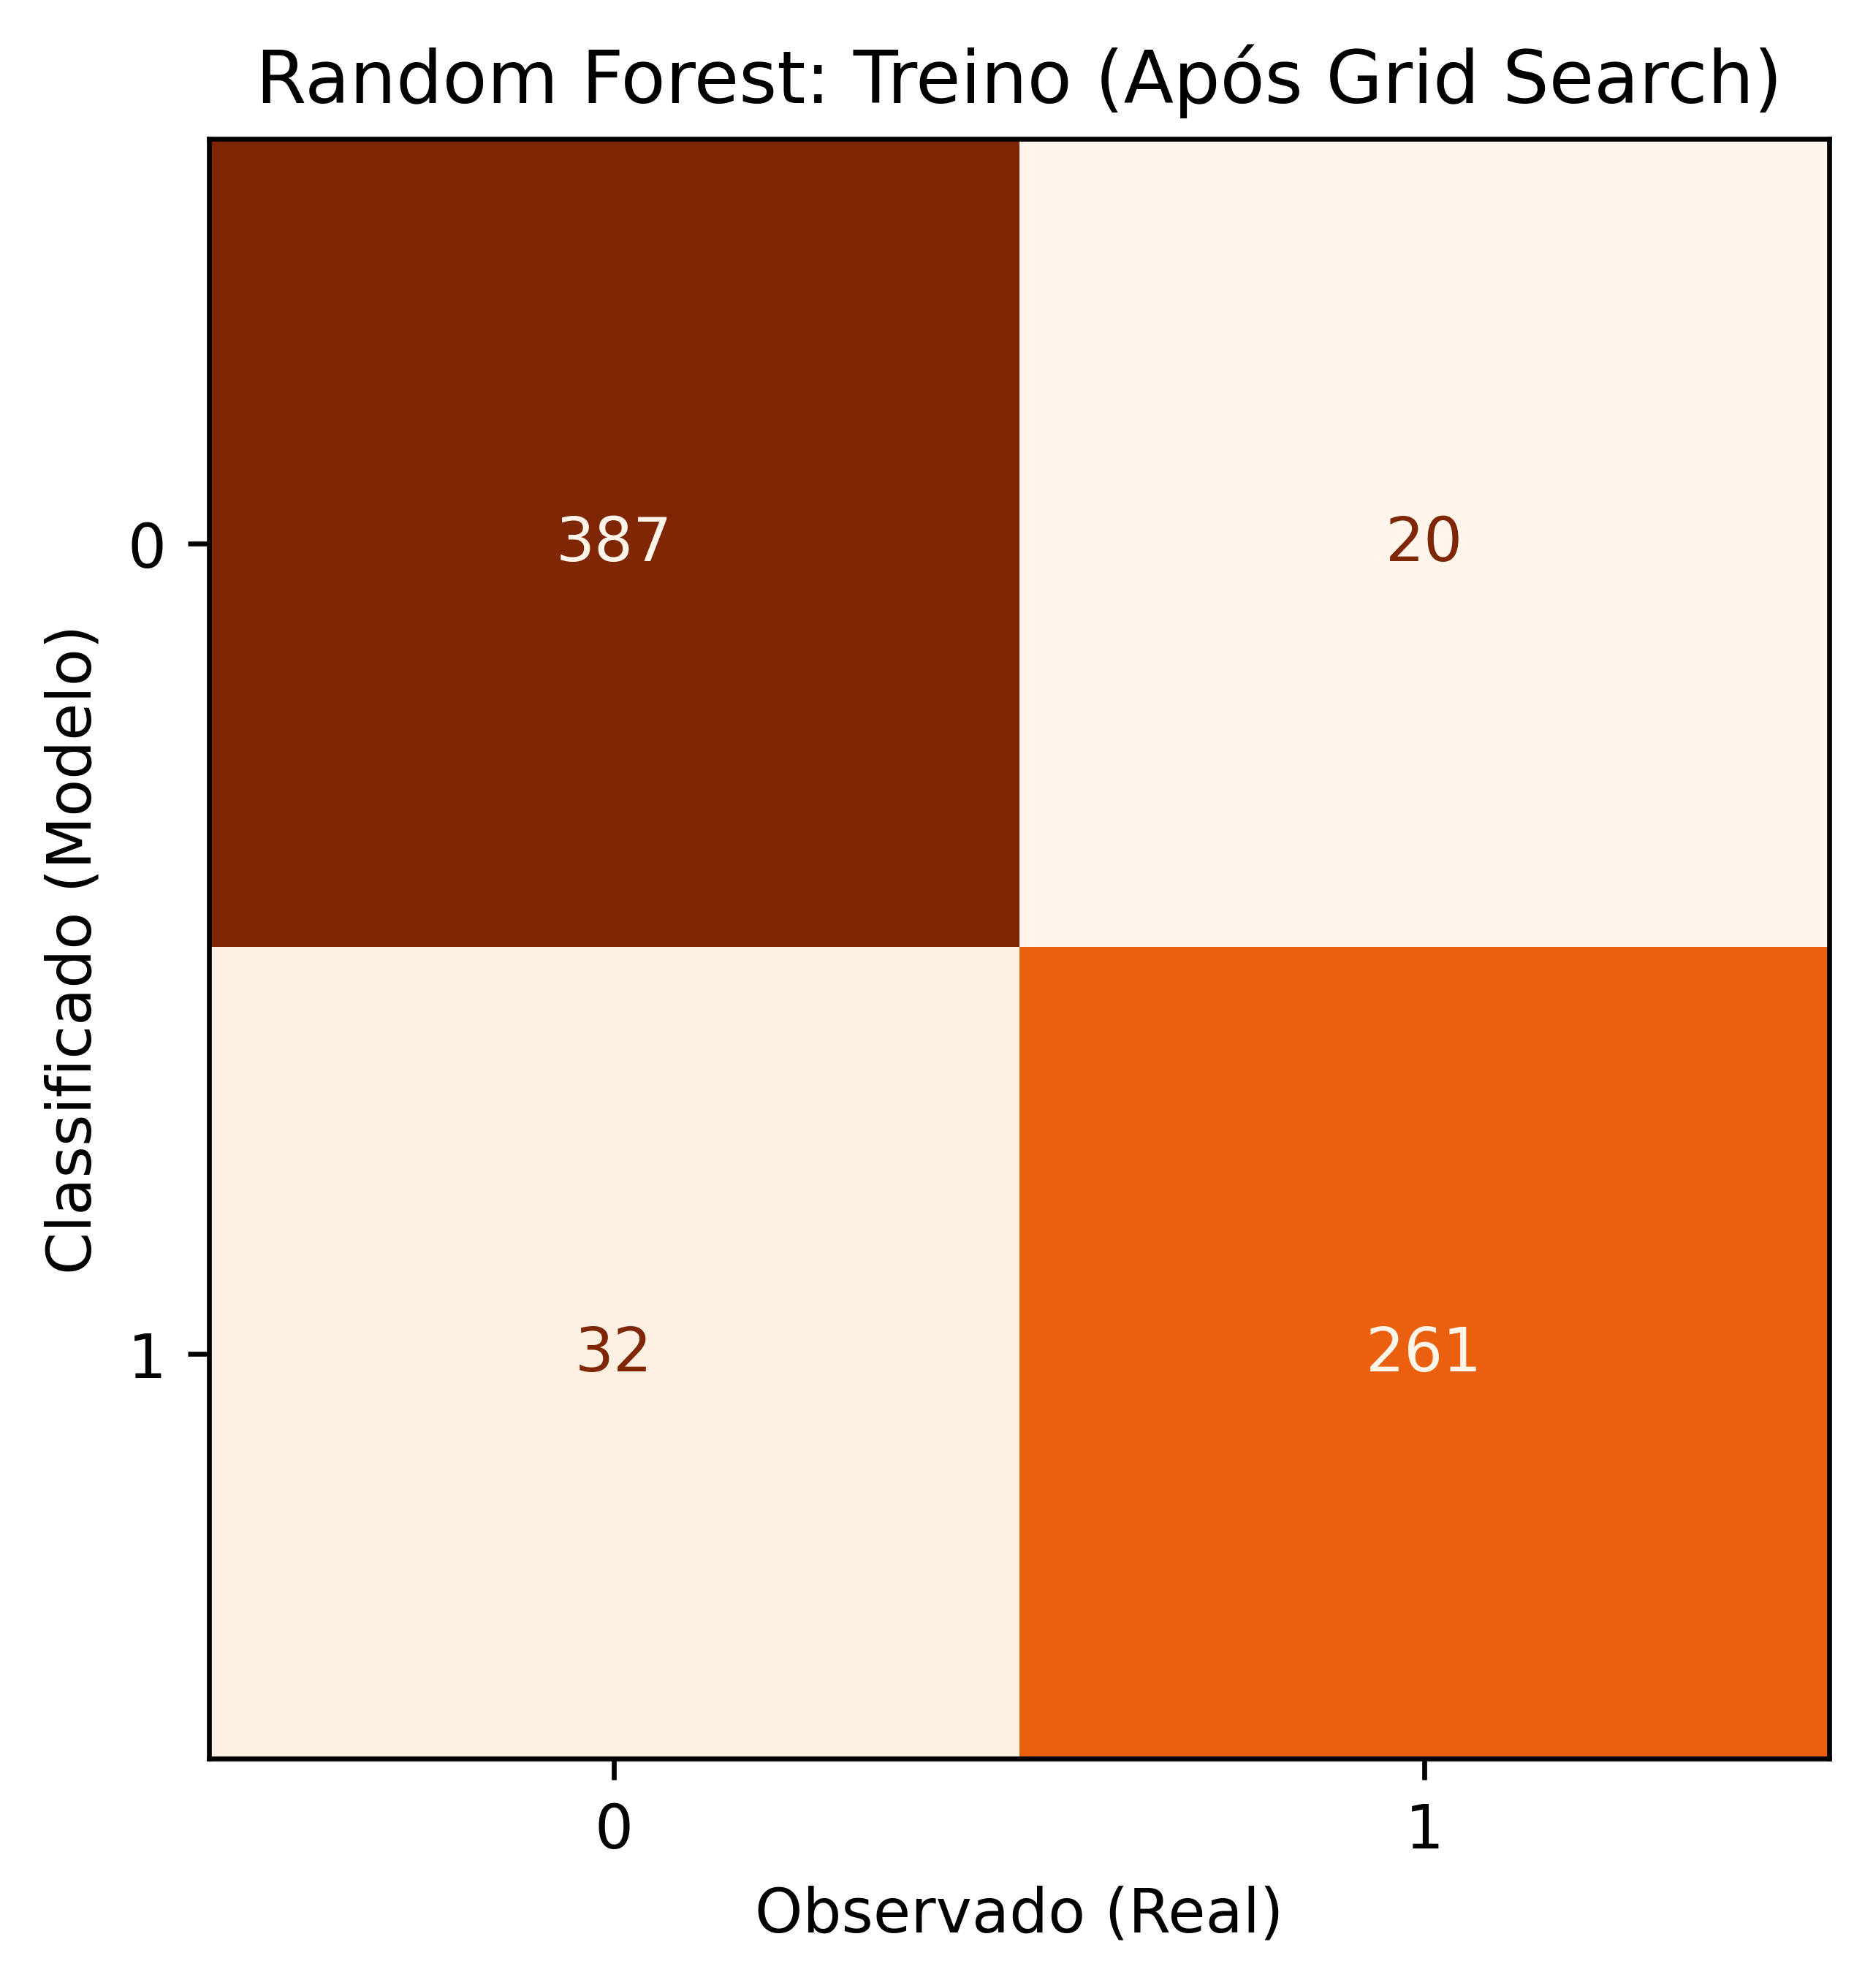

Avaliação da RF Após Grid Search (Base de Treino)
Acurácia: 92.6%
Sensibilidade: 92.9%
Especificidade: 92.4%
Precision: 89.1%


In [34]:
#%% Matriz de confusão (base de treino)

rf_grid_cm_train = confusion_matrix(rf_grid_pred_train_class, y_train)
cm_rf_grid_train = ConfusionMatrixDisplay(rf_grid_cm_train)

plt.rcParams['figure.dpi'] = 600
cm_rf_grid_train.plot(colorbar=False, cmap='Oranges')
plt.title('Random Forest: Treino (Após Grid Search)')
plt.xlabel('Observado (Real)')
plt.ylabel('Classificado (Modelo)')
plt.show()

acc_rf_grid_train = accuracy_score(y_train, rf_grid_pred_train_class)
sens_rf_grid_train = recall_score(y_train, rf_grid_pred_train_class, pos_label=1)
espec_rf_grid_train = recall_score(y_train, rf_grid_pred_train_class, pos_label=0)
prec_rf_grid_train = precision_score(y_train, rf_grid_pred_train_class)

print("Avaliação da RF Após Grid Search (Base de Treino)")
print(f"Acurácia: {acc_rf_grid_train:.1%}")
print(f"Sensibilidade: {sens_rf_grid_train:.1%}")
print(f"Especificidade: {espec_rf_grid_train:.1%}")
print(f"Precision: {prec_rf_grid_train:.1%}")

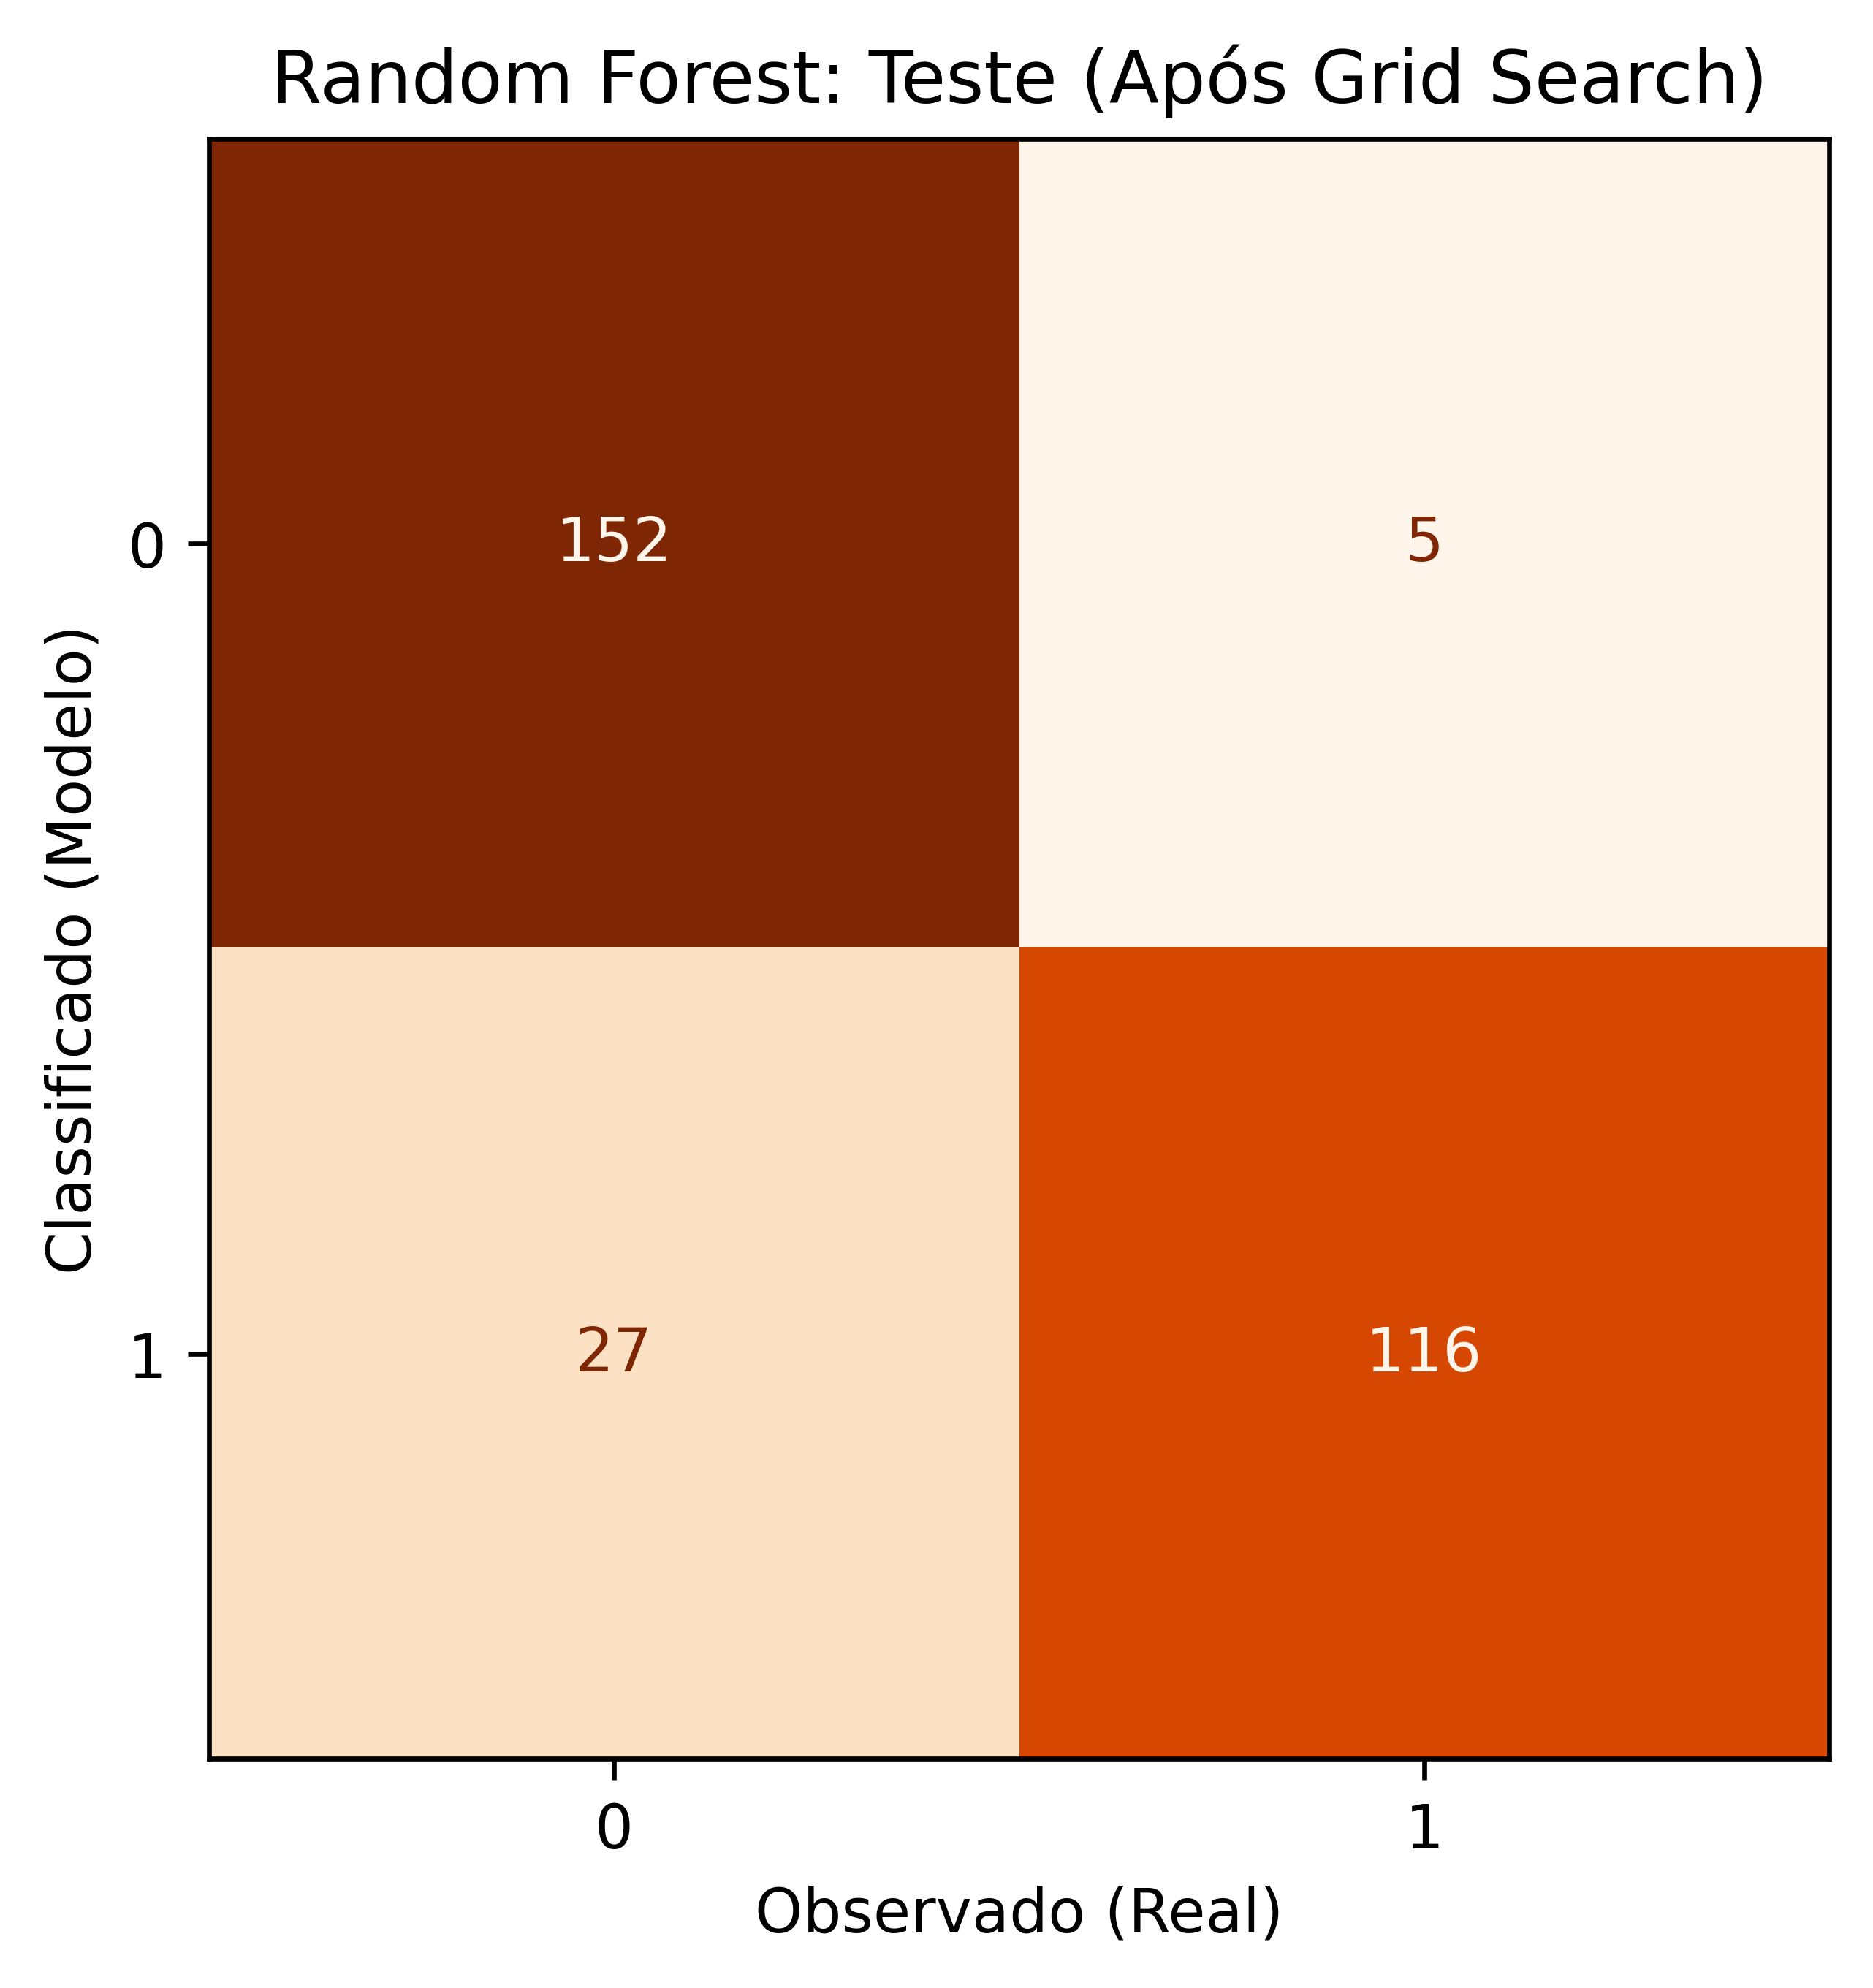

Avaliação da RF Após Grid Search (Base de Teste)
Acurácia: 89.3%
Sensibilidade: 95.9%
Especificidade: 84.9%
Precision: 81.1%


In [35]:
#%% Matriz de confusão (base de teste)

rf_grid_cm_test = confusion_matrix(rf_grid_pred_test_class, y_test)
cm_rf_grid_test = ConfusionMatrixDisplay(rf_grid_cm_test)

plt.rcParams['figure.dpi'] = 600
cm_rf_grid_test.plot(colorbar=False, cmap='Oranges')
plt.title('Random Forest: Teste (Após Grid Search)')
plt.xlabel('Observado (Real)')
plt.ylabel('Classificado (Modelo)')
plt.show()

acc_rf_grid_test = accuracy_score(y_test, rf_grid_pred_test_class)
sens_rf_grid_test = recall_score(y_test, rf_grid_pred_test_class, pos_label=1)
espec_rf_grid_test = recall_score(y_test, rf_grid_pred_test_class, pos_label=0)
prec_rf_grid_test = precision_score(y_test, rf_grid_pred_test_class)

print("Avaliação da RF Após Grid Search (Base de Teste)")
print(f"Acurácia: {acc_rf_grid_test:.1%}")
print(f"Sensibilidade: {sens_rf_grid_test:.1%}")
print(f"Especificidade: {espec_rf_grid_test:.1%}")
print(f"Precision: {prec_rf_grid_test:.1%}")

In [36]:
#%% Importância das variáveis preditoras

rf_features = pd.DataFrame({'features':X.columns.tolist(),
                            'importance':rf_best.feature_importances_})

print(rf_features)


       features  importance
0           Age    0.550833
1  AnnualSalary    0.446053
2   Gender_Male    0.003114


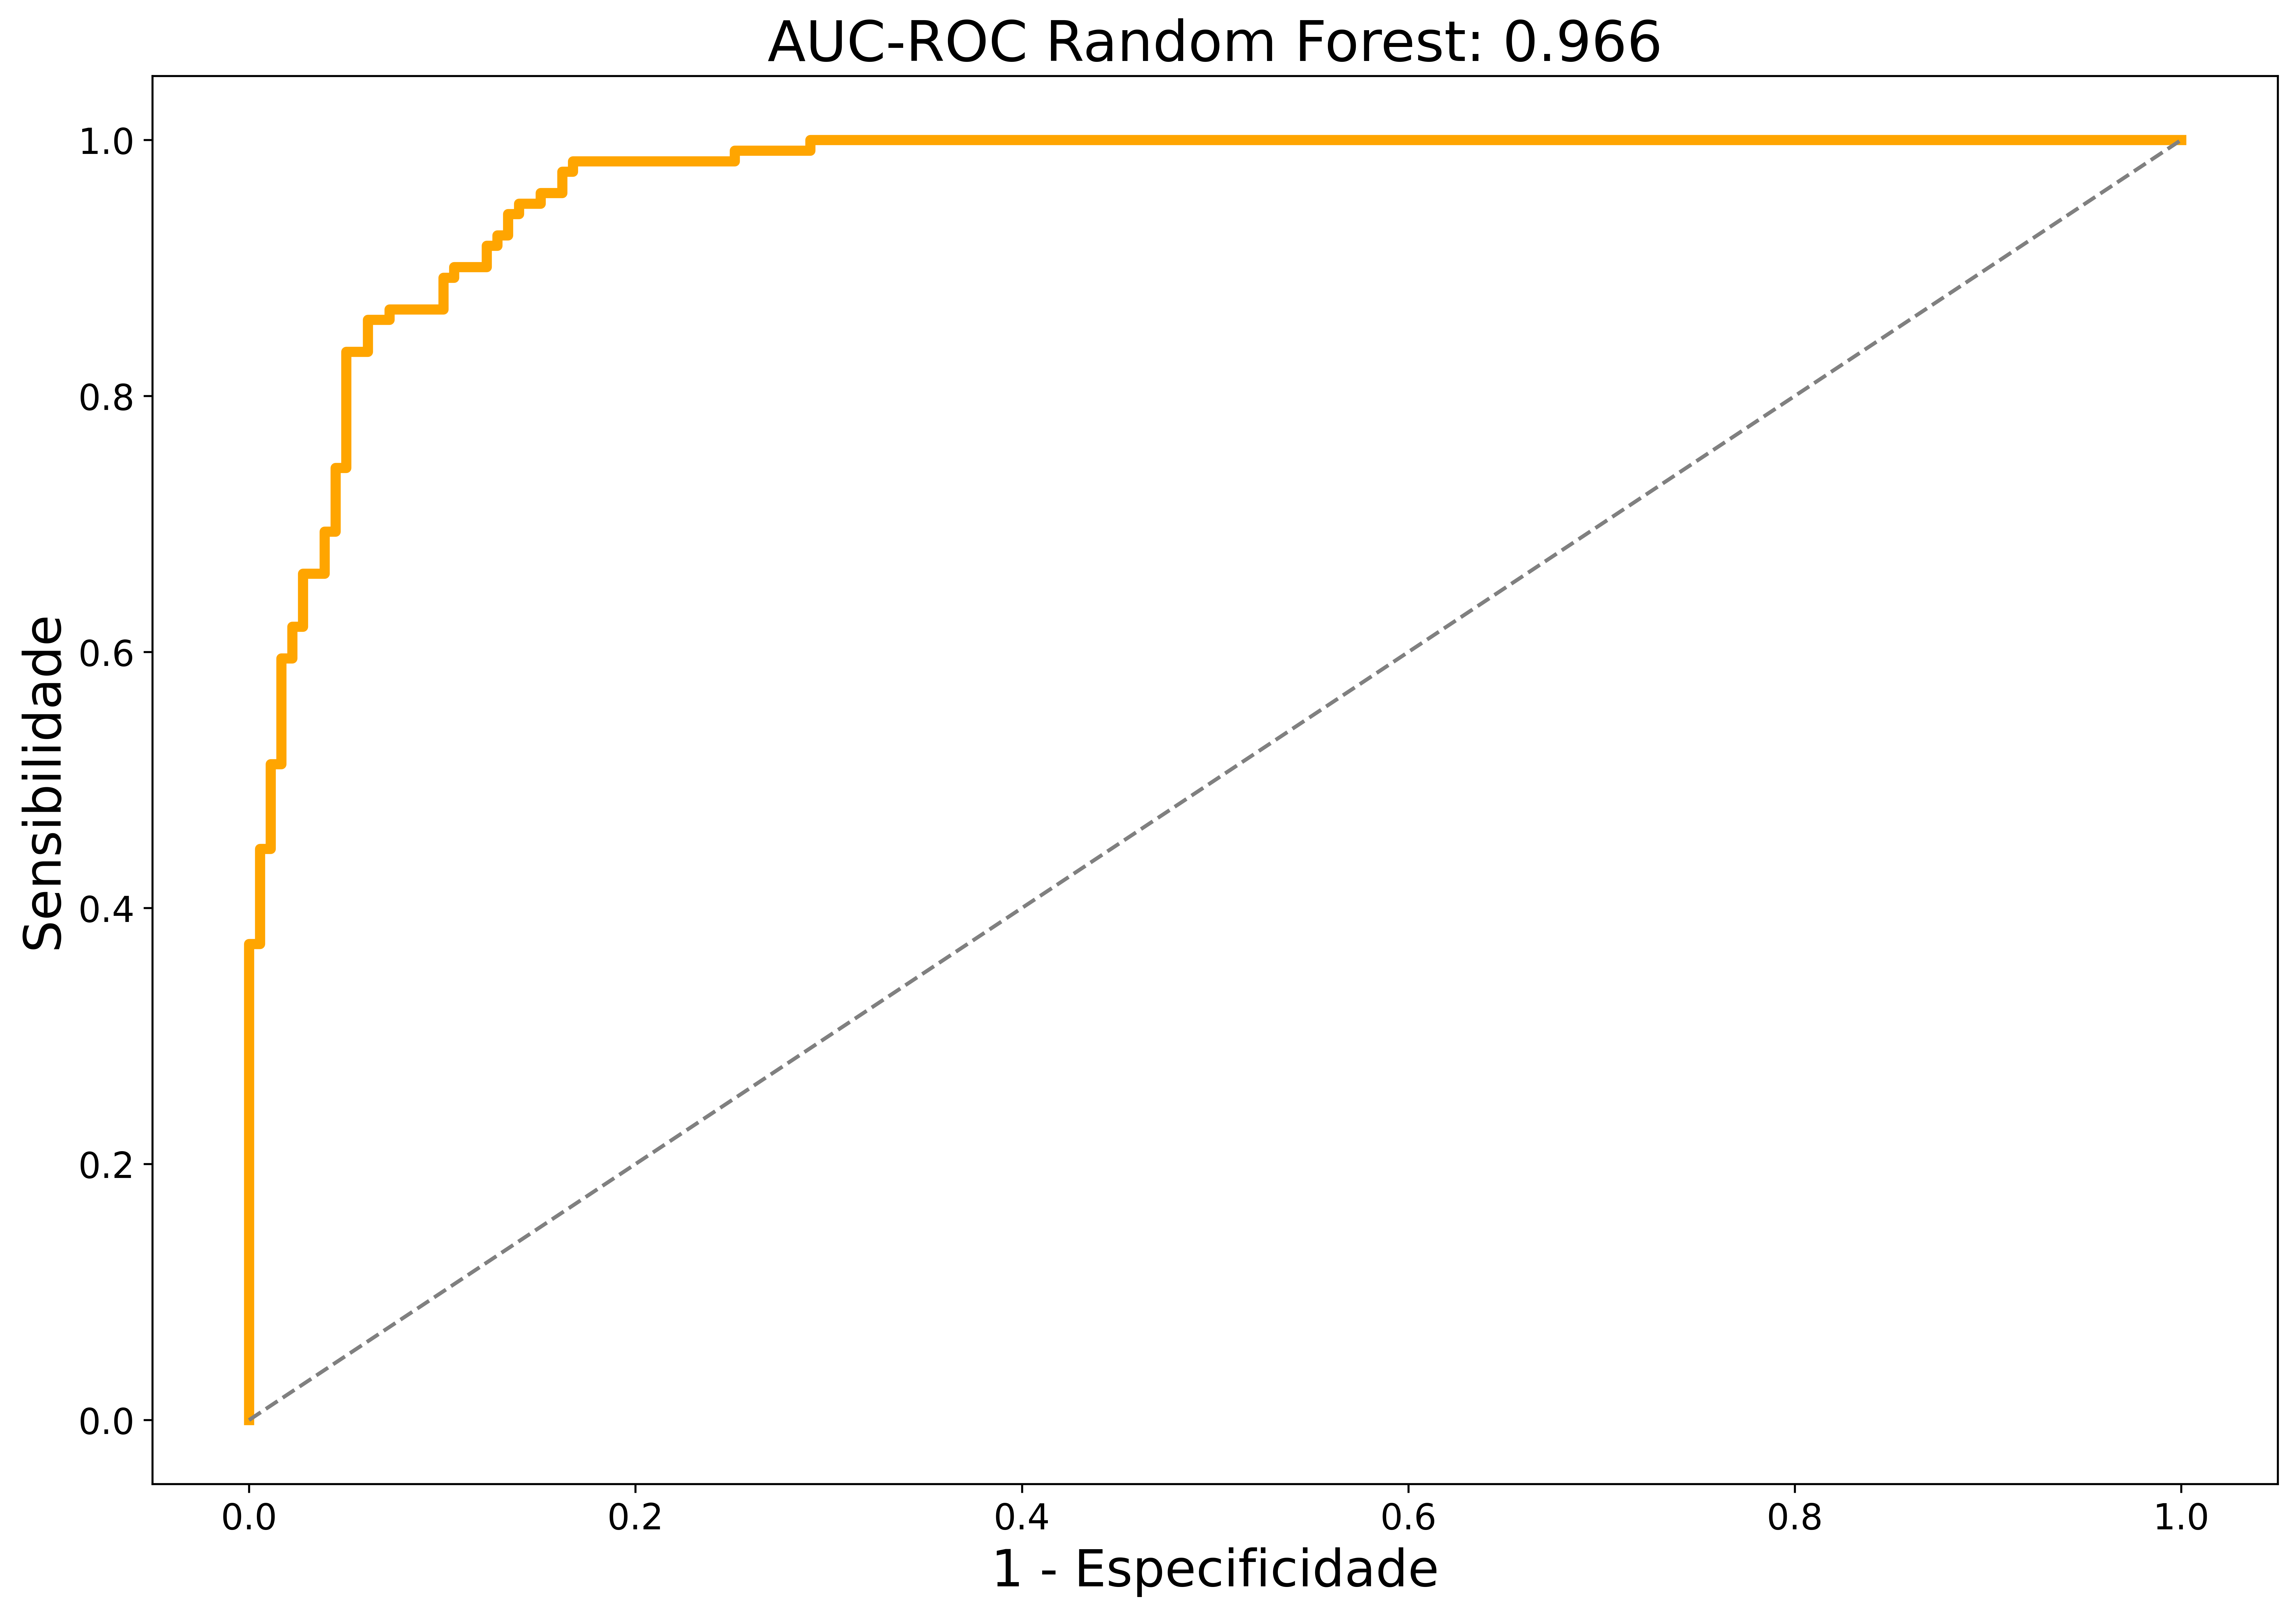

In [37]:
#%% Curva ROC (base de teste)

# Parametrizando a função da curva ROC (real vs. previsto)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf_grid_pred_test_prob[:,1])
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plotando a curva ROC
plt.figure(figsize=(15,10), dpi=600)
plt.plot(fpr_rf, tpr_rf, color='Orange', linewidth=4)
plt.plot(fpr_rf, fpr_rf, color='gray', linestyle='dashed')
plt.title('AUC-ROC Random Forest: %g' % round(roc_auc_rf, 3), fontsize=22)
plt.xlabel('1 - Especificidade', fontsize=20)
plt.ylabel('Sensibilidade', fontsize=20)
plt.xticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.show()

In [38]:
#%%######################### XGBoost ##########################################
###############################################################################
#%% Estimando um XGBoost

xgb_clf = XGBClassifier(n_estimators=50,
                        max_depth=3,
                        colsample_bytree=0.5,
                        learning_rate=0.1,
                        random_state=100)
xgb_clf.fit(X_train, y_train)

## Alguns hiperparâmetros do modelo

# n_estimators: qtde de árvores no modelo
# max_depth: profundidade máxima das árvores
# colsample_bytree: percentual de variáveis X subamostradas para cada árvore
# learning_rate: taxa de aprendizagem

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, random_state=100, ...)

In [39]:
#%% Grid Search

# Especificar a lista de hiperparâmetros
param_grid_xgb = {
    'n_estimators': [100, 500],
    'max_depth': [3, 5],
    'colsample_bytree': [0.5, 1],
    'learning_rate': [0.01, 0.1]
}

# Identificar o algoritmo em uso
xgb_grid = XGBClassifier(random_state=100)

# Treinar os modelos para o grid search
xgb_grid_model = GridSearchCV(estimator = xgb_grid, 
                              param_grid = param_grid_xgb,
                              scoring='accuracy', 
                              cv=5, verbose=2)

xgb_grid_model.fit(X_train, y_train)

# Verificando os melhores parâmetros obtidos
xgb_grid_model.best_params_

# Gerando o modelo com os melhores hiperparâmetros
xgb_best = xgb_grid_model.best_estimator_

#%% Importância das variáveis preditoras

xgb_features = pd.DataFrame({'features':X.columns.tolist(),
                            'importance':xgb_best.feature_importances_})

print(xgb_features)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, n_estimators=500; total time=   0.2s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, n_estimators=500; total time=   0.1s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, n_estimators=500; total time=   0.2s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, n_estimators=500; total time=   0.2s
[CV] END colsample_bytree=0.5,

In [40]:
#%% Obtendo os valores preditos pelo XGBoost

# Predict na base de treinamento
xgb_grid_pred_train_class = xgb_best.predict(X_train)
xgb_grid_pred_train_prob = xgb_best.predict_proba(X_train)

# Predict na base de testes
xgb_grid_pred_test_class = xgb_best.predict(X_test)
xgb_grid_pred_test_prob = xgb_best.predict_proba(X_test)

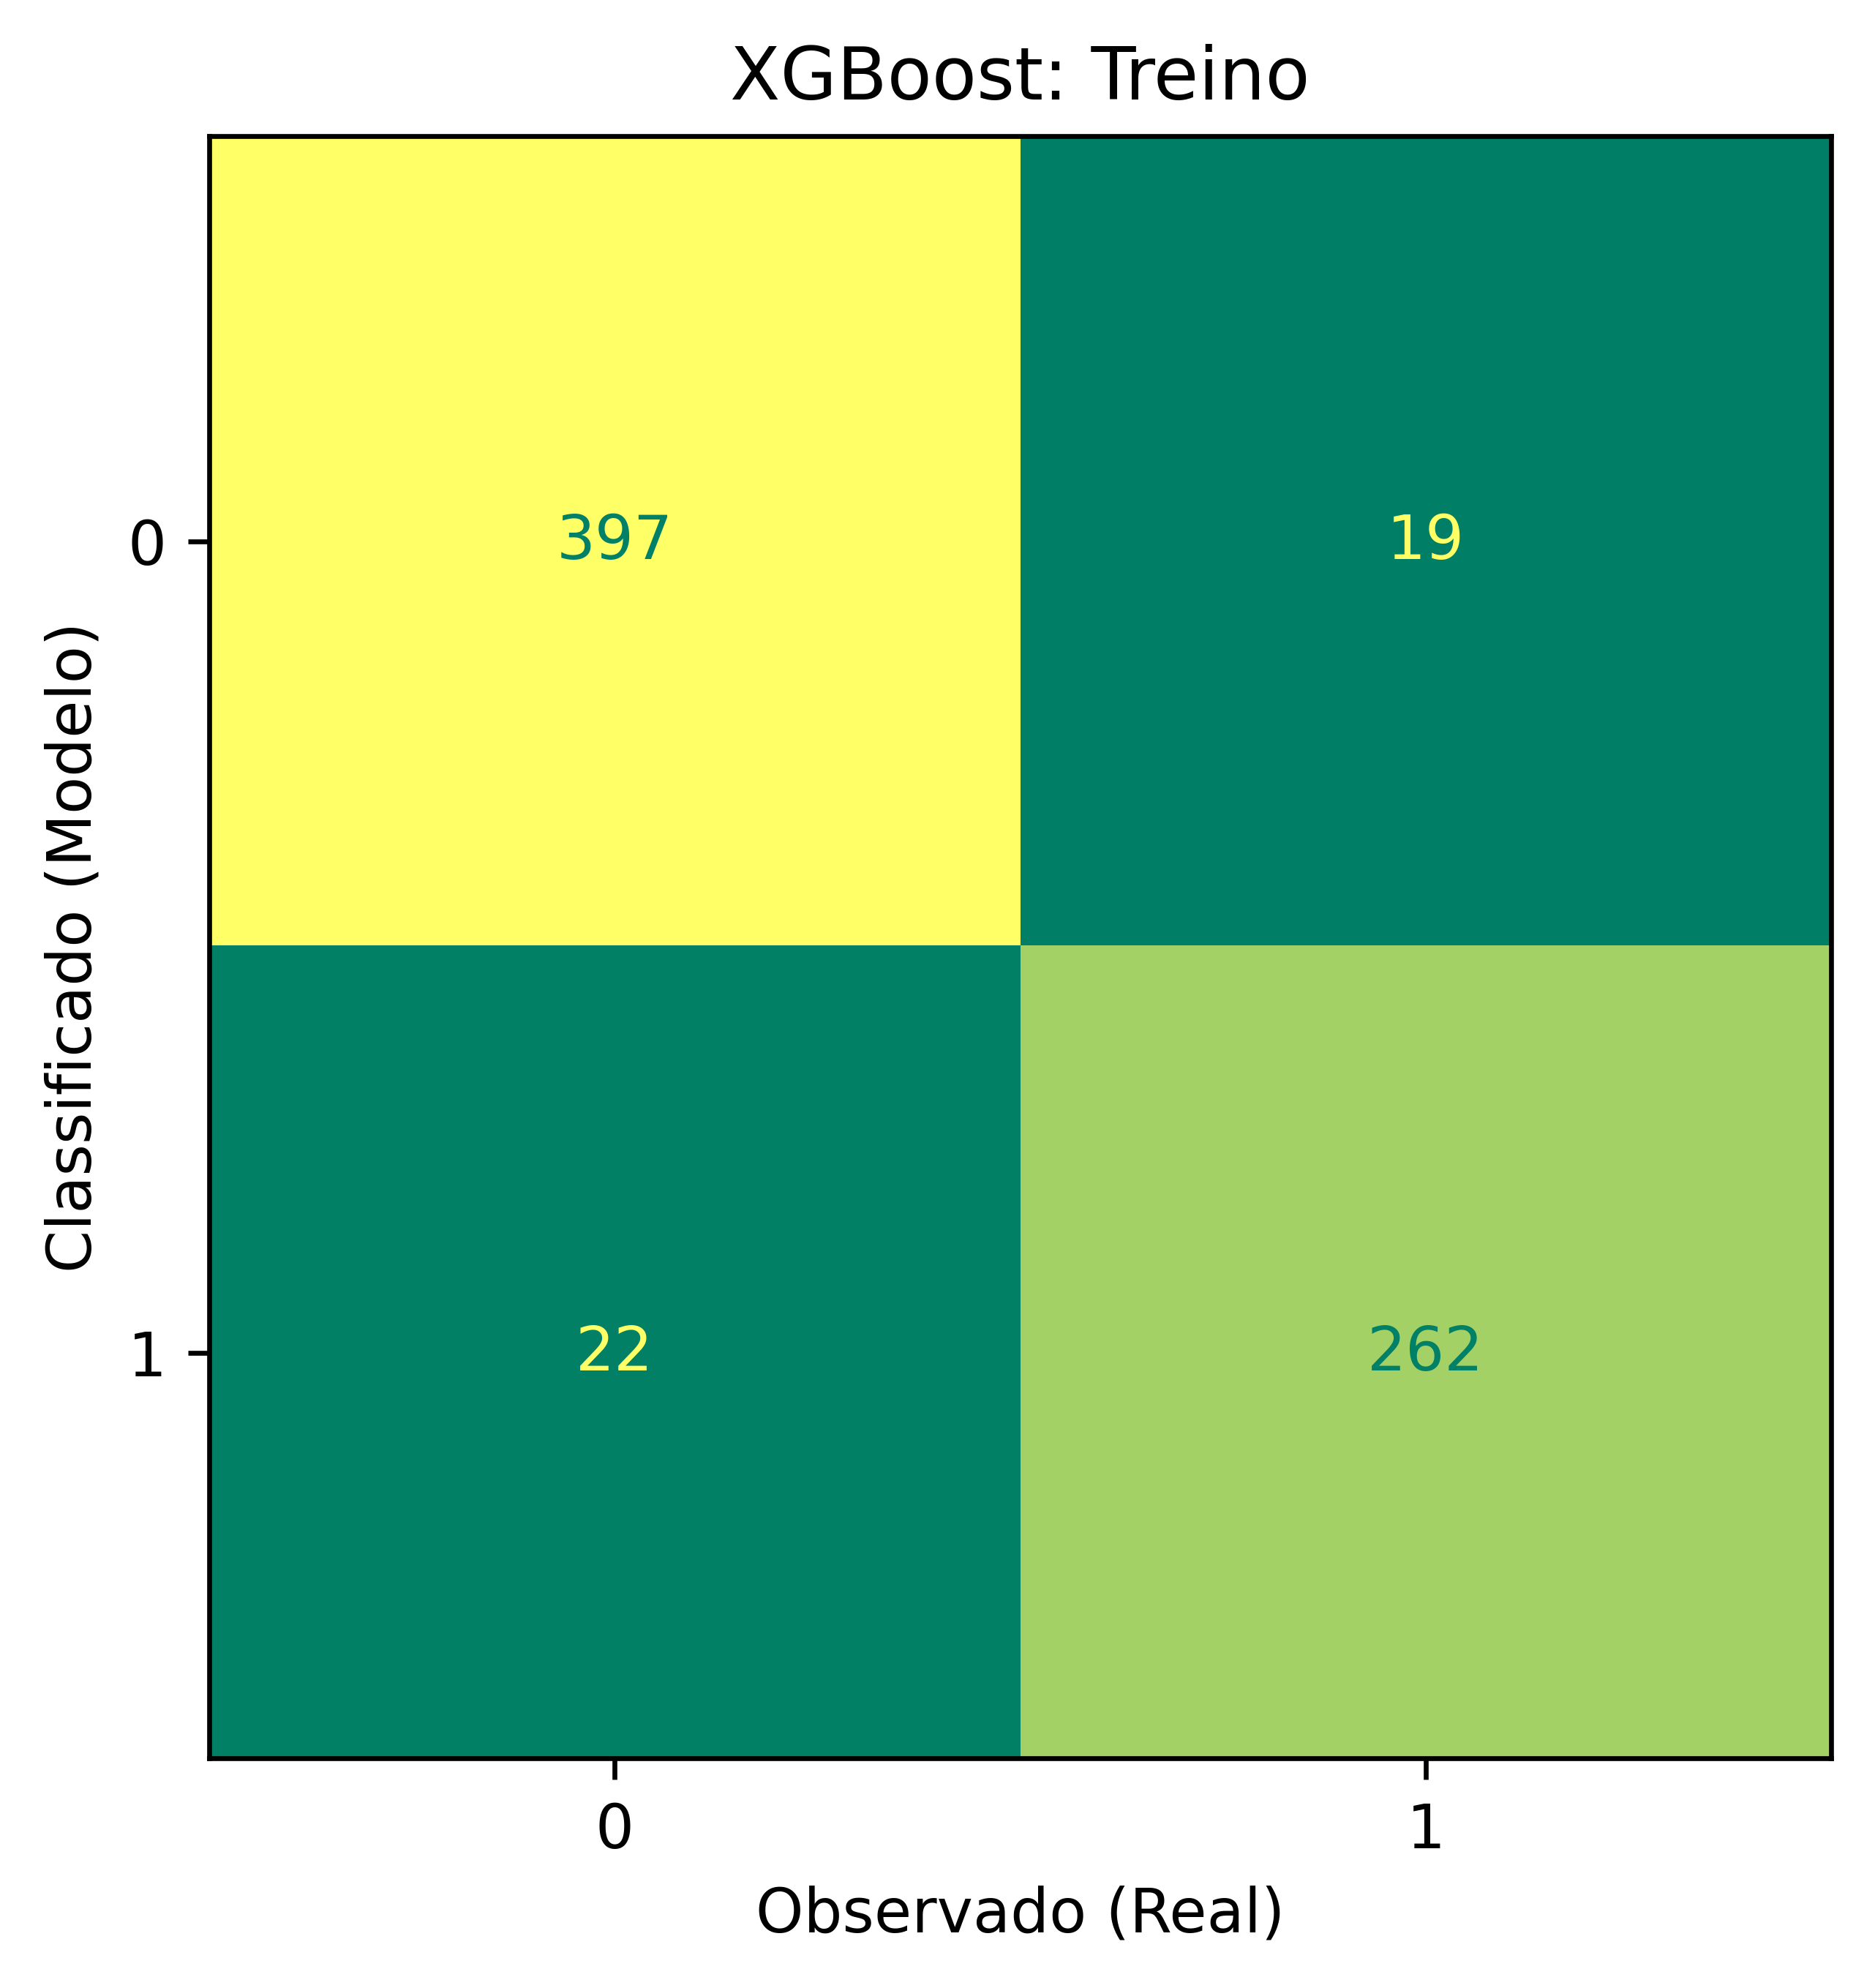

Avaliação do XGBoost (Base de Treino)
Acurácia: 94.1%
Sensibilidade: 93.2%
Especificidade: 94.7%
Precision: 92.3%


In [41]:
#%% Matriz de confusão (base de treino)

xgb_cm_train = confusion_matrix(xgb_grid_pred_train_class, y_train)
cm_xgb_train = ConfusionMatrixDisplay(xgb_cm_train)

plt.rcParams['figure.dpi'] = 600
cm_xgb_train.plot(colorbar=False, cmap='summer')
plt.title('XGBoost: Treino')
plt.xlabel('Observado (Real)')
plt.ylabel('Classificado (Modelo)')
plt.show()

acc_xgb_train = accuracy_score(y_train, xgb_grid_pred_train_class)
sens_xgb_train = recall_score(y_train, xgb_grid_pred_train_class, pos_label=1)
espec_xgb_train = recall_score(y_train, xgb_grid_pred_train_class, pos_label=0)
prec_xgb_train = precision_score(y_train, xgb_grid_pred_train_class)

print("Avaliação do XGBoost (Base de Treino)")
print(f"Acurácia: {acc_xgb_train:.1%}")
print(f"Sensibilidade: {sens_xgb_train:.1%}")
print(f"Especificidade: {espec_xgb_train:.1%}")
print(f"Precision: {prec_xgb_train:.1%}")

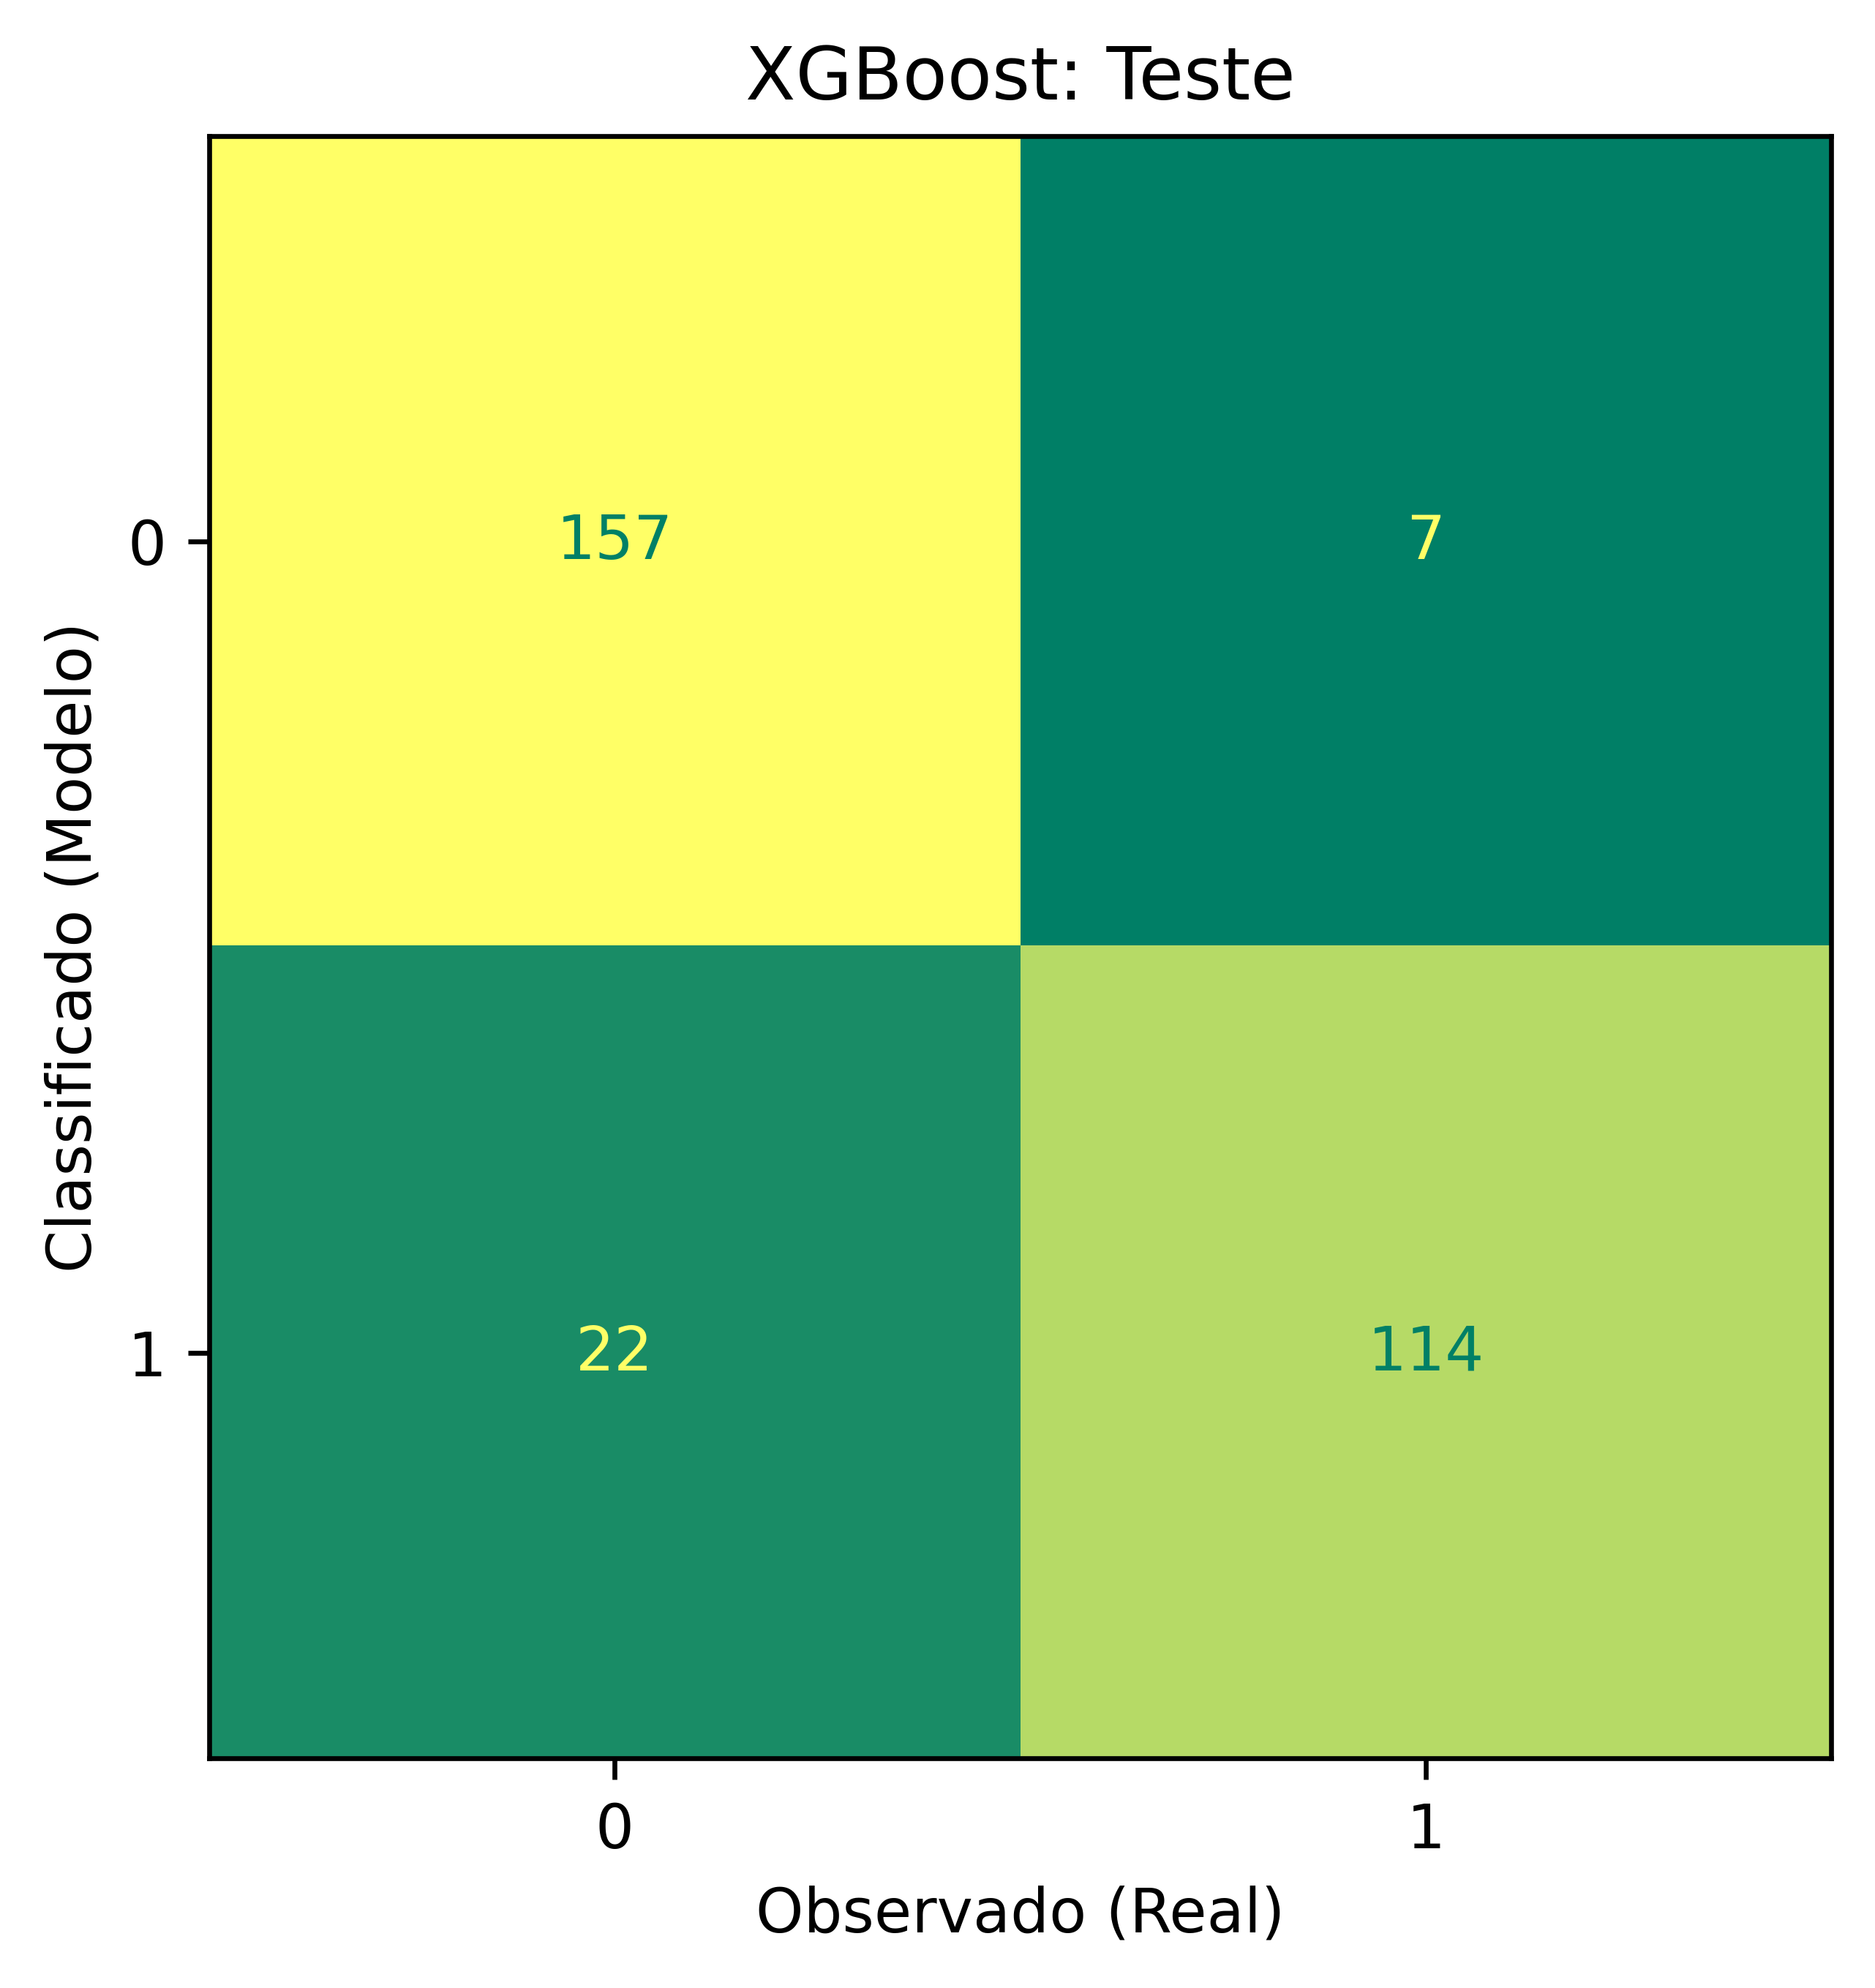

Avaliação do XGBoost (Base de Teste)
Acurácia: 90.3%
Sensibilidade: 94.2%
Especificidade: 87.7%
Precision: 83.8%


In [42]:
#%% Matriz de confusão (base de teste)

xgb_cm_test = confusion_matrix(xgb_grid_pred_test_class, y_test)
cm_xgb_test = ConfusionMatrixDisplay(xgb_cm_test)

plt.rcParams['figure.dpi'] = 600
cm_xgb_test.plot(colorbar=False, cmap='summer')
plt.title('XGBoost: Teste')
plt.xlabel('Observado (Real)')
plt.ylabel('Classificado (Modelo)')
plt.show()

acc_xgb_test = accuracy_score(y_test, xgb_grid_pred_test_class)
sens_xgb_test = recall_score(y_test, xgb_grid_pred_test_class, pos_label=1)
espec_xgb_test = recall_score(y_test, xgb_grid_pred_test_class, pos_label=0)
prec_xgb_test = precision_score(y_test, xgb_grid_pred_test_class)

print("Avaliação do XGBoost (Base de Teste)")
print(f"Acurácia: {acc_xgb_test:.1%}")
print(f"Sensibilidade: {sens_xgb_test:.1%}")
print(f"Especificidade: {espec_xgb_test:.1%}")
print(f"Precision: {prec_xgb_test:.1%}")

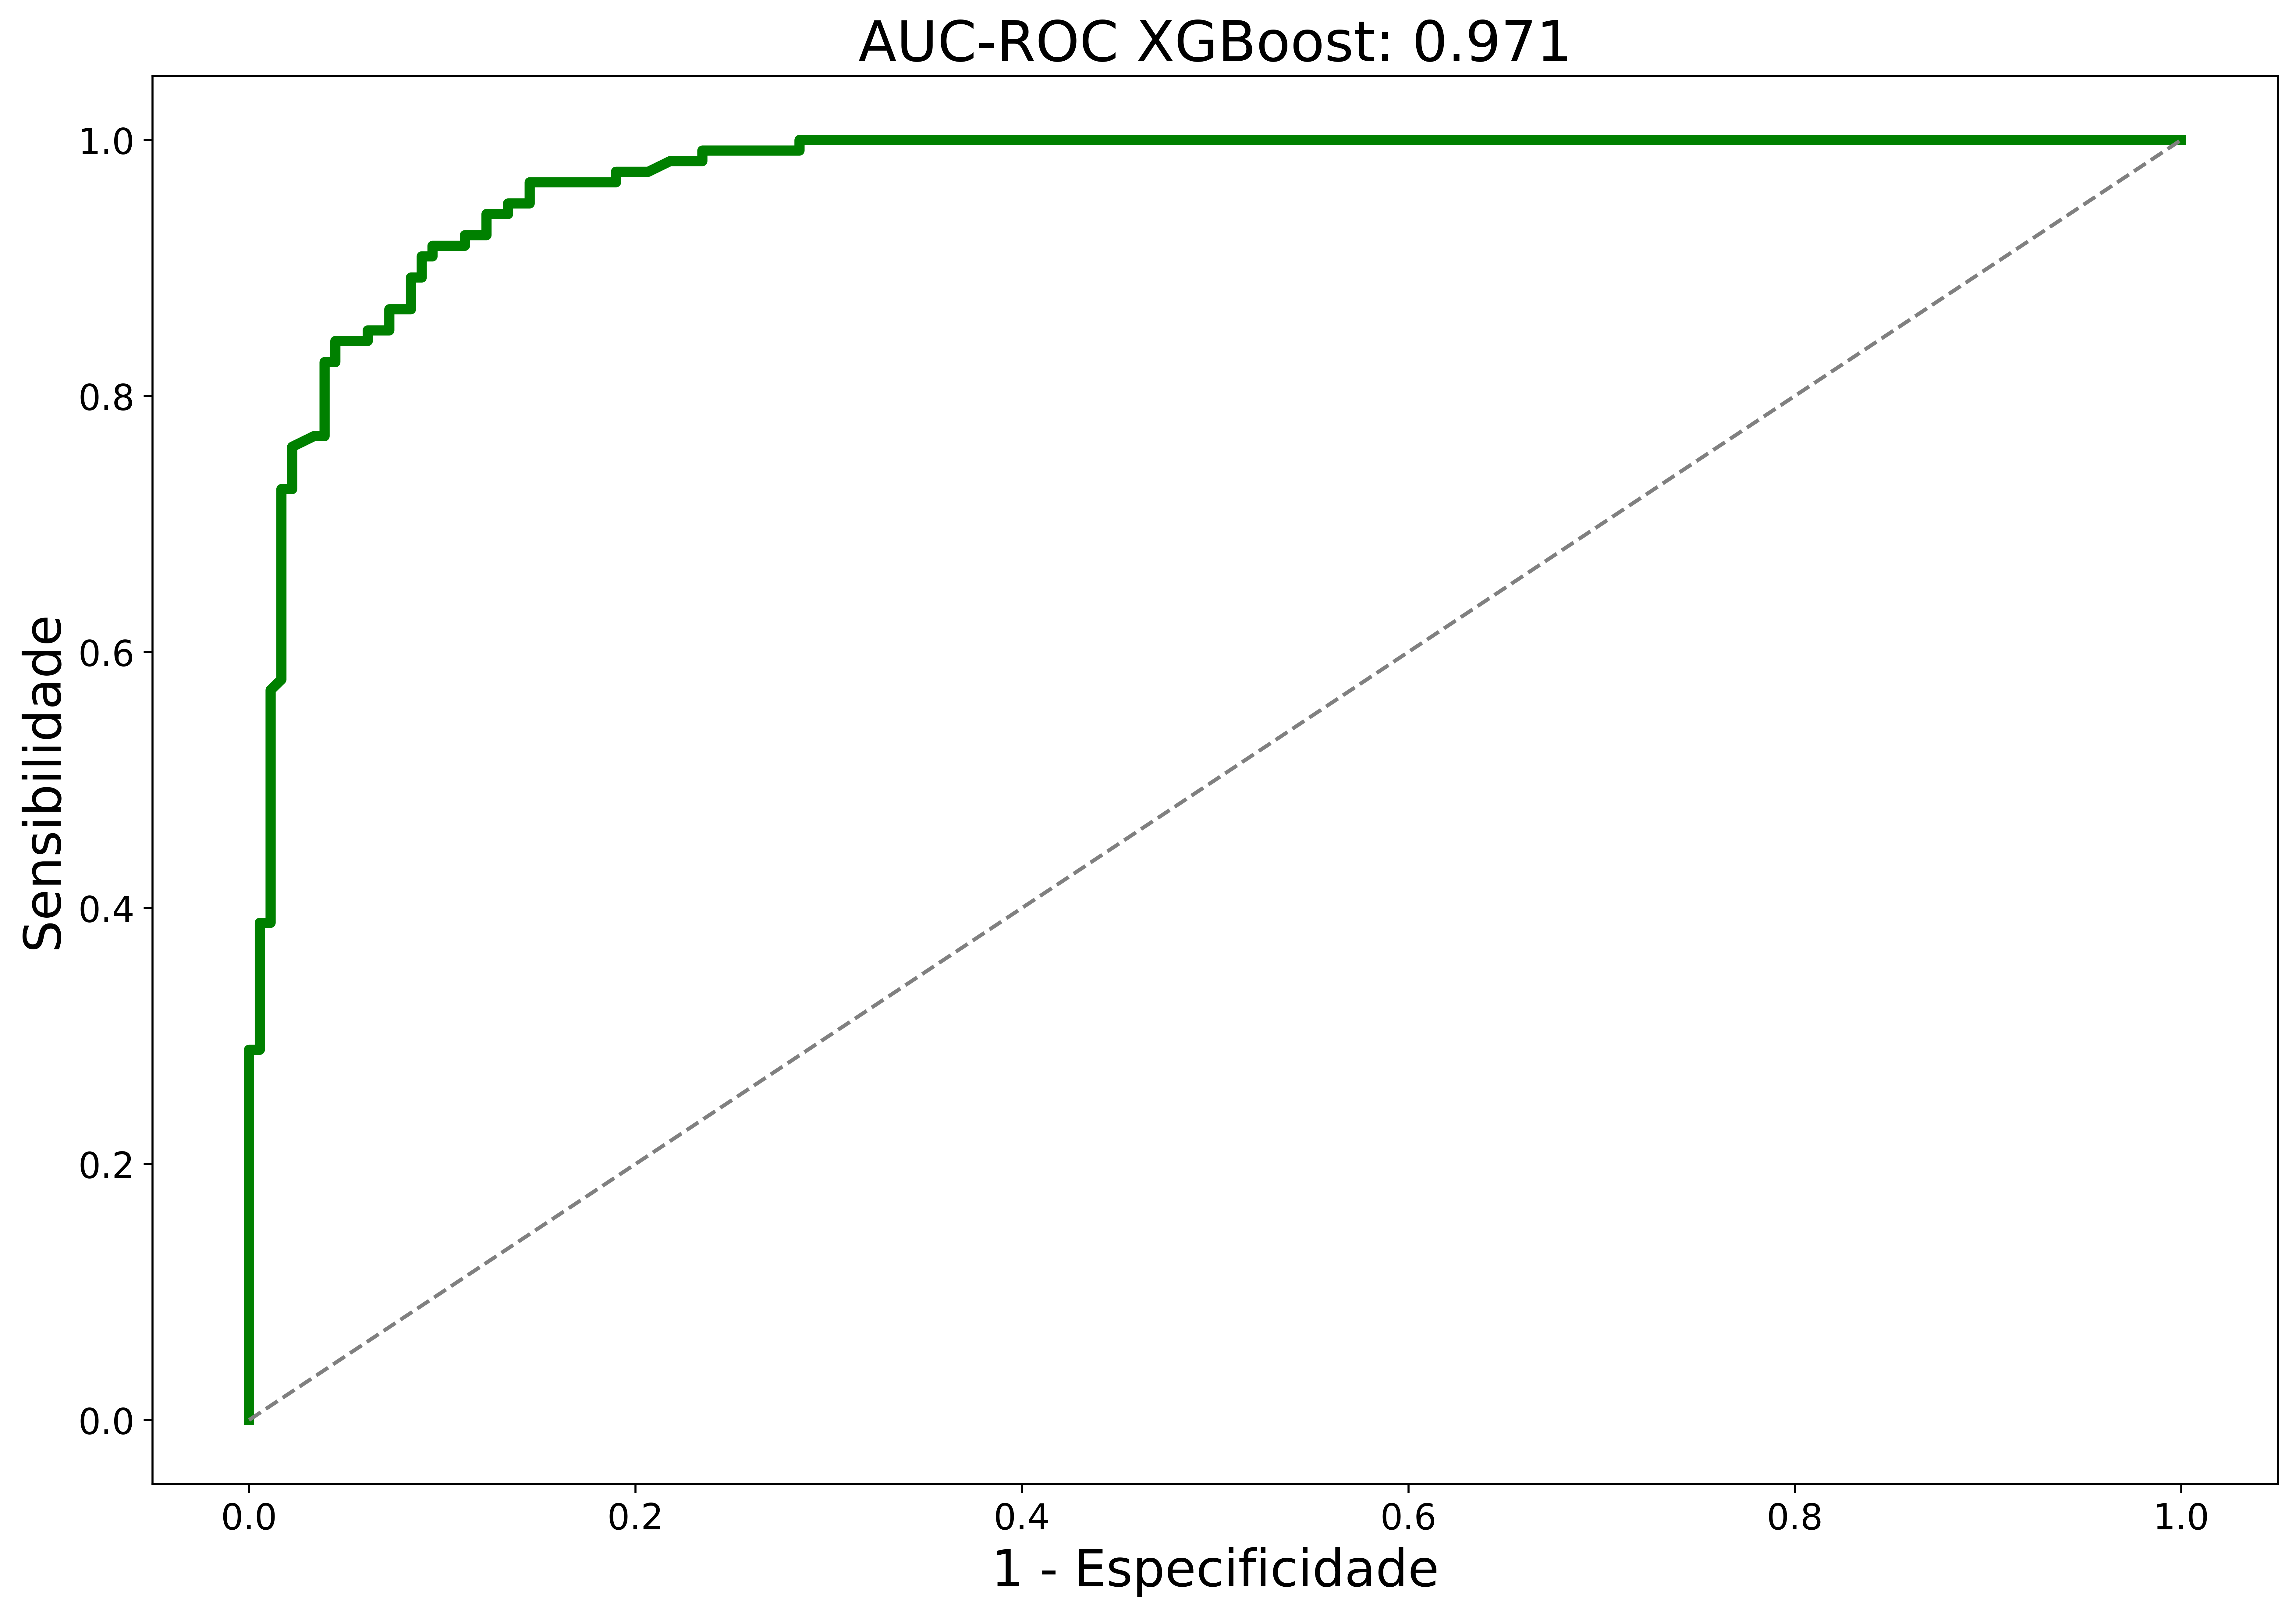

In [43]:
#%% Curva ROC (base de teste)

# Parametrizando a função da curva ROC (real vs. previsto)
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, xgb_grid_pred_test_prob[:,1])
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plotando a curva ROC
plt.figure(figsize=(15,10), dpi=600)
plt.plot(fpr_xgb, tpr_xgb, color='green', linewidth=4)
plt.plot(fpr_xgb, fpr_xgb, color='gray', linestyle='dashed')
plt.title('AUC-ROC XGBoost: %g' % round(roc_auc_xgb, 3), fontsize=22)
plt.xlabel('1 - Especificidade', fontsize=20)
plt.ylabel('Sensibilidade', fontsize=20)
plt.xticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.show()

In [44]:
#%% Realizando previsões para observações de fora da amostra

novo_cliente = pd.DataFrame({'Age': [40],
                             'AnnualSalary': [70000],
                             'Gender_Male': [1]})

cliente_tree = tree_clf_aj.predict_proba(novo_cliente)
cliente_rf = rf_best.predict_proba(novo_cliente)
cliente_xgb = xgb_best.predict_proba(novo_cliente)

#%% Fim!